#🔍 **Cel projektu**

##Celem projektu było stworzenie modelu klasyfikującego obrazy ziaren ryżu do jednej z pięciu klas:
### **Arborio, Basmati, Ipsala, Jasmine, Karacadag.**


# DANE

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rice-image-dataset


In [ ]:
from google.colab import files
files.upload()


In [ ]:
import os
import zipfile

# Tworzymy folder .kaggle i kopiujemy kaggle.json tam
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Pobieramy dane z Kaggle
!kaggle datasets download --force  muratkokludataset/rice-image-dataset


Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
 54% 119M/219M [00:00<00:00, 1.24GB/s]
100% 219M/219M [00:00<00:00, 850MB/s] 


In [ ]:
# Wypakuj plik ZIP
with zipfile.ZipFile("rice-image-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("rice_dataset")

# Sprawdźmy strukturę folderów
!ls rice_dataset


Rice_Image_Dataset


In [ ]:
import os

data_dir = "rice_dataset/Rice_Image_Dataset"
classes = [folder for folder in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, folder))]
print("Klasy:", classes)

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} obrazków")

Klasy: ['Ipsala', 'Basmati', 'Jasmine', 'Karacadag', 'Arborio']
Ipsala: 15000 obrazków
Basmati: 15000 obrazków
Jasmine: 15000 obrazków
Karacadag: 15000 obrazków
Arborio: 15000 obrazków


In [ ]:
import shutil
import random
import os

small_dataset_dir = "rice_small_dataset"
os.makedirs(small_dataset_dir, exist_ok=True)


data_dir = "rice_dataset/Rice_Image_Dataset"
classes = os.listdir(data_dir)

if os.path.exists(small_dataset_dir):
    shutil.rmtree(small_dataset_dir)
os.makedirs(small_dataset_dir, exist_ok=True)

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        new_class_path = os.path.join(small_dataset_dir, class_name)
        os.makedirs(new_class_path, exist_ok=True)

        images = os.listdir(class_path)
        random.shuffle(images)
        selected_images = images[:500]  # tylko 500 zdjęć na klasę

        for img in selected_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(new_class_path, img))
    else:

        print(f"Skipping non-directory item: {class_path}")


print("Zrobiono mały zbiór danych :)")

Skipping non-directory item: rice_dataset/Rice_Image_Dataset/Rice_Citation_Request.txt
Zrobiono mały zbiór danych :)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 96, 96  # mały rozmiar do szybkiego trenowania
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    small_dataset_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    small_dataset_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [ ]:
for class_name in classes:
    class_path = os.path.join(small_dataset_dir, class_name)
    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} zdjęć")

Ipsala: 500 zdjęć
Basmati: 500 zdjęć
Jasmine: 500 zdjęć
Karacadag: 500 zdjęć
Arborio: 500 zdjęć


Mały zbiór danych znajduje się pod ścieżką: rice_small_dataset


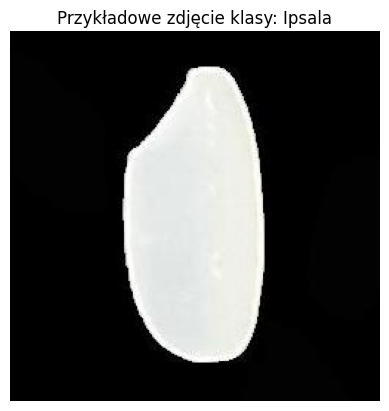

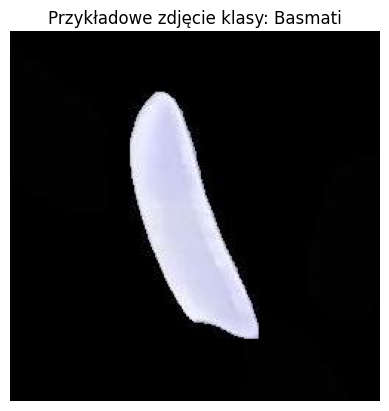

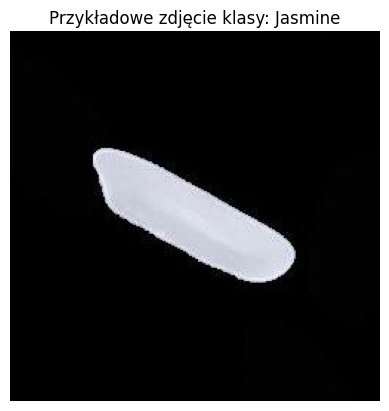

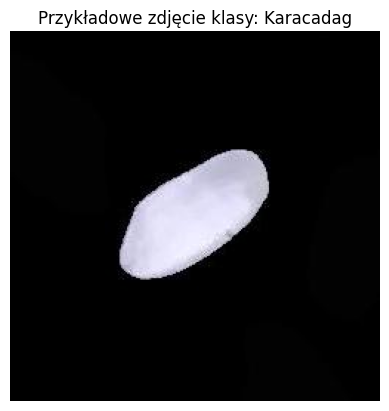

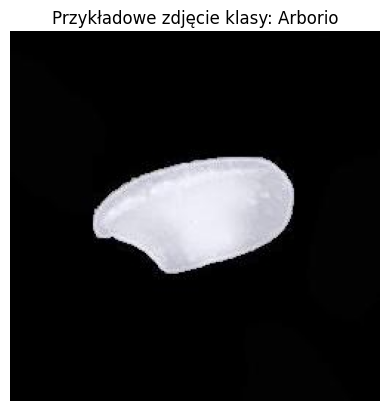

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


print(f"Mały zbiór danych znajduje się pod ścieżką: {small_dataset_dir}")

# Upewnij się, że small_dataset_dir i classes są zdefiniowane
# Jeśli ten fragment kodu jest uruchamiany niezależnie, upewnij się, że te zmienne są ustawione.
if not 'small_dataset_dir' in globals() or not 'classes' in globals():
    small_dataset_dir = "rice_small_dataset"
    # Sprawdź, czy katalog istnieje, zanim spróbujesz wyświetlić zdjęcia
    if not os.path.exists(small_dataset_dir):
        print(f"Katalog '{small_dataset_dir}' nie istnieje. Upewnij się, że dane zostały pobrane i przetworzone.")
    else:
        classes = [folder for folder in os.listdir(small_dataset_dir) if os.path.isdir(os.path.join(small_dataset_dir, folder))]


# Wyświetlanie przykładowych zdjęć z każdej klasy
if os.path.exists(small_dataset_dir):
    for class_name in classes:
        class_path = os.path.join(small_dataset_dir, class_name)
        # Upewnij się, że ścieżka jest katalogiem
        if os.path.isdir(class_path):
            images_in_class = os.listdir(class_path)
            if images_in_class: # Sprawdź czy lista nie jest pusta
                # Wybierz losowe zdjęcie z klasy
                random_image_name = random.choice(images_in_class)
                random_image_path = os.path.join(class_path, random_image_name)

                # Wyświetl zdjęcie
                img = mpimg.imread(random_image_path)
                plt.imshow(img)
                plt.title(f"Przykładowe zdjęcie klasy: {class_name}")
                plt.axis('off')  # Ukryj osie
                plt.show()
            else:
                print(f"Brak zdjęć w klasie: {class_name}")
else:
    print(f"Katalog '{small_dataset_dir}' nie istnieje. Nie można wyświetlić przykładowych zdjęć.")




--- Podsumowanie liczby zdjęć na klasę ---
    Klasa  Oryginalny Zbiór  Mały Zbiór (500/klasa)
   Ipsala             15000                     500
  Basmati             15000                     500
  Jasmine             15000                     500
Karacadag             15000                     500
  Arborio             15000                     500


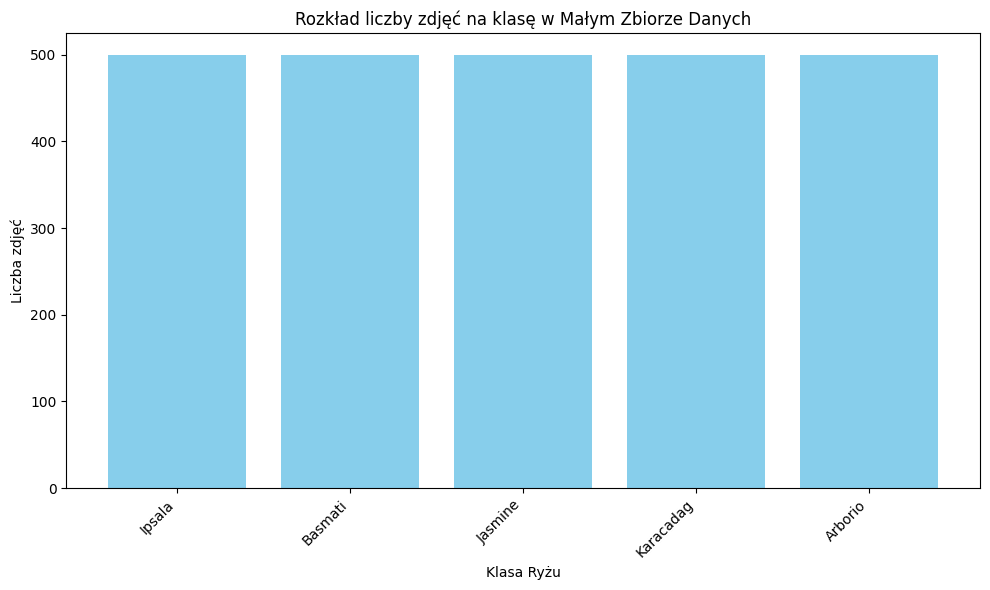

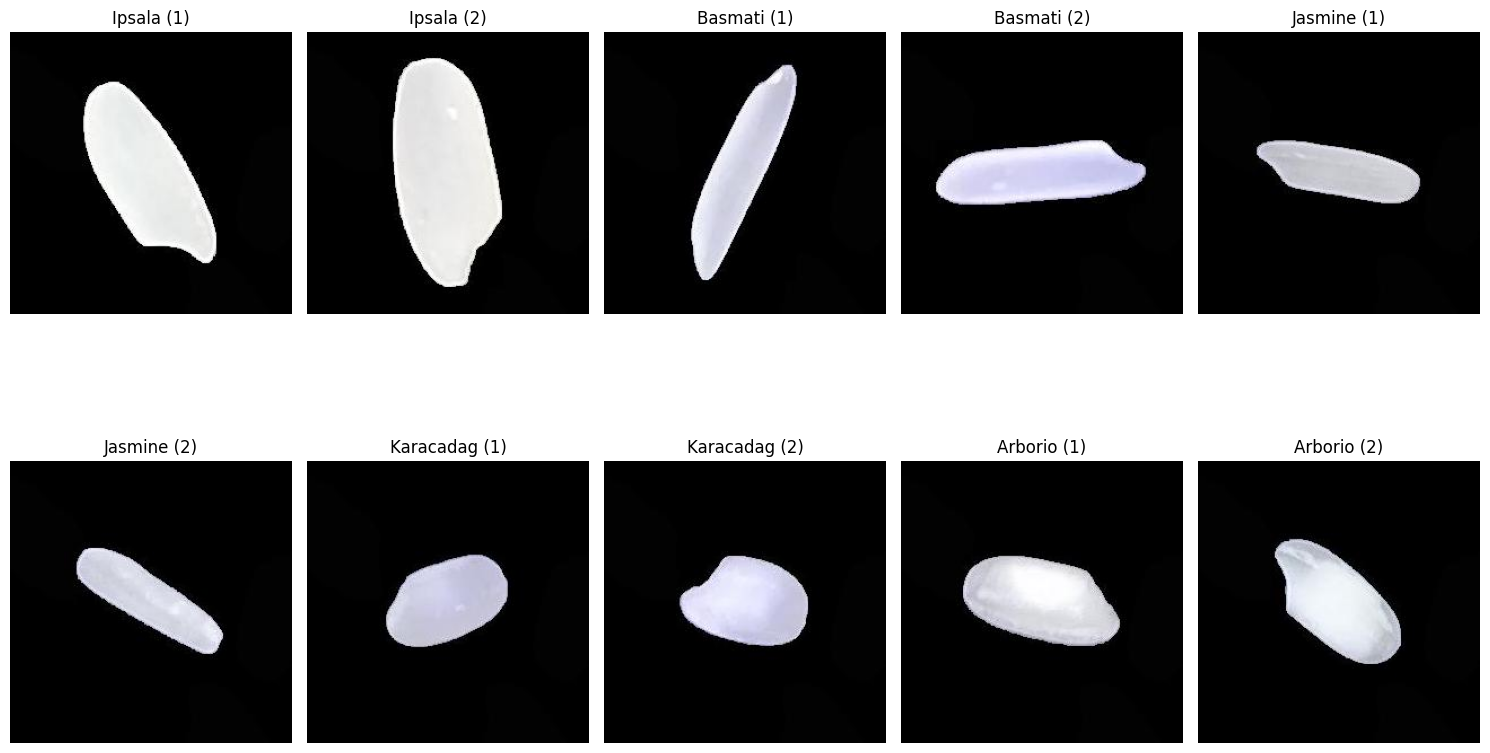

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

if not 'data_dir' in globals():
    data_dir = "rice_dataset/Rice_Image_Dataset"
if not 'small_dataset_dir' in globals():
    small_dataset_dir = "rice_small_dataset"

# 1. Tabela podsumowująca liczbę zdjęć w każdej klasie
print("\n--- Podsumowanie liczby zdjęć na klasę ---")
data = []
classes = [folder for folder in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, folder))]

for class_name in classes:
    original_count = 0
    small_count = 0

    original_class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(original_class_path):
        original_count = len(os.listdir(original_class_path))

    small_class_path = os.path.join(small_dataset_dir, class_name)
    if os.path.isdir(small_class_path):
        small_count = len(os.listdir(small_class_path))

    data.append({'Klasa': class_name, 'Oryginalny Zbiór': original_count, 'Mały Zbiór (500/klasa)': small_count})

df_summary = pd.DataFrame(data)
print(df_summary.to_string(index=False))


# 2. Wykres słupkowy z rozkładem liczby zdjęć w małym zbiorze
if os.path.exists(small_dataset_dir):
    class_counts_small = {}
    for class_name in classes:
         class_path = os.path.join(small_dataset_dir, class_name)
         if os.path.isdir(class_path):
            class_counts_small[class_name] = len(os.listdir(class_path))

    if class_counts_small:
        plt.figure(figsize=(10, 6))
        plt.bar(class_counts_small.keys(), class_counts_small.values(), color='skyblue')
        plt.title('Rozkład liczby zdjęć na klasę w Małym Zbiorze Danych')
        plt.xlabel('Klasa Ryżu')
        plt.ylabel('Liczba zdjęć')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Brak danych o liczbie zdjęć w '{small_dataset_dir}' do stworzenia wykresu.")
else:
    print(f"Katalog '{small_dataset_dir}' nie istnieje. Nie można stworzyć wykresu rozkładu klas.")


# 3. Wyświetlenie kilku przykładowych obrazów dla każdej klasy w jednej siatce
if os.path.exists(small_dataset_dir):
    plt.figure(figsize=(15, 10))
    rows = 2  # Liczba wierszy w siatce
    cols = len(classes) # Liczba kolumn (jedna dla każdej klasy)
    images_per_class_display = 2 # Ile zdjęć z każdej klasy pokazać

    plot_index = 1
    for class_name in classes:
        class_path = os.path.join(small_dataset_dir, class_name)
        if os.path.isdir(class_path):
            images_in_class = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))] # Tylko pliki
            if images_in_class:
                # Wybierz losowe zdjęcia
                selected_images = random.sample(images_in_class, min(images_per_class_display, len(images_in_class)))

                for i, img_name in enumerate(selected_images):
                    img_path = os.path.join(class_path, img_name)
                    img = mpimg.imread(img_path)

                    plt.subplot(rows, cols, plot_index)
                    plt.imshow(img)
                    plt.title(f"{class_name} ({i+1})")
                    plt.axis('off')
                    plot_index += 1
            else:
                 # Jeśli brak zdjęć w katalogu, dodaj puste miejsce lub informację
                 plt.subplot(rows, cols, plot_index)
                 plt.text(0.5, 0.5, f"Brak zdjęć w\n{class_name}", horizontalalignment='center', verticalalignment='center')
                 plt.axis('off')
                 plot_index += 1


    plt.tight_layout()
    plt.show()
else:
    print(f"Katalog '{small_dataset_dir}' nie istnieje. Nie można wyświetlić siatki przykładowych zdjęć.")



# BEZ NORMALIZACJI KTÓRĄ PRZYPADKOWO WSZĘDZIE WSADZAŁAM WCZEŚNIEJ!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10  # tylko jedna epoka na CPU, żeby dało się porównać

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 3. Budowa modelu ResNet50 bez transfer learningu ===
base_model = ResNet50(weights=None, include_top=False, input_shape=(96, 96, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.5040 - loss: 1.9338 - val_accuracy: 0.2000 - val_loss: 56.8934
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.8813 - loss: 0.2973 - val_accuracy: 0.2360 - val_loss: 3.5080
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9411 - loss: 0.1709 - val_accuracy: 0.4120 - val_loss: 2.1001
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.9522 - loss: 0.1317 - val_accuracy: 0.6900 - val_loss: 1.7150
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9826 - loss: 0.0621 - val_accuracy: 0.9320 - val_loss: 0.2751
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.9763 - loss: 0.0726 - val_accuracy: 0.8660 - val_loss: 0.3432
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.9429 - loss: 0.1868 - val_accuracy: 0.4680 - val_loss: 3.5058
Epoch 8/10
63/63 ━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 709ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Arborio       0.93      0.94      0.94       100
     Basmati       0.97      0.99      0.98       100
      Ipsala       0.00      0.00      0.00       100
     Jasmine       0.49      0.94      0.64       100
   Karacadag       0.95      0.99      0.97       100

    accuracy                           0.77       500
   macro avg       0.67      0.77      0.71       500
weighted avg       0.67      0.77      0.71       500



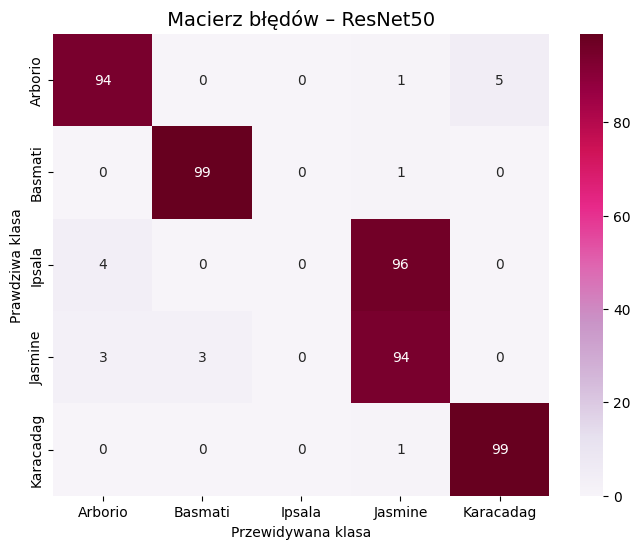

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet50 ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

model.save('resnet50_rice_model_bezNormalizacji.keras')


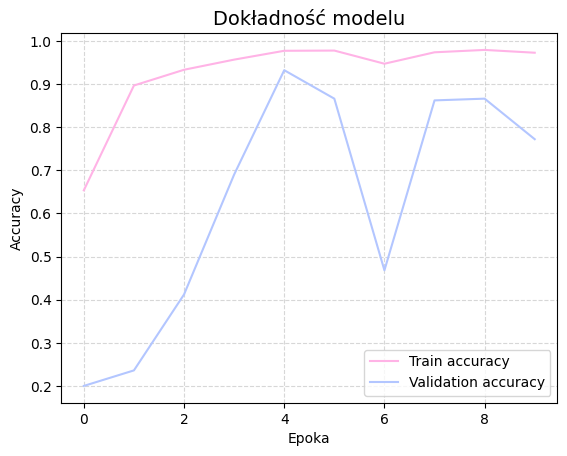

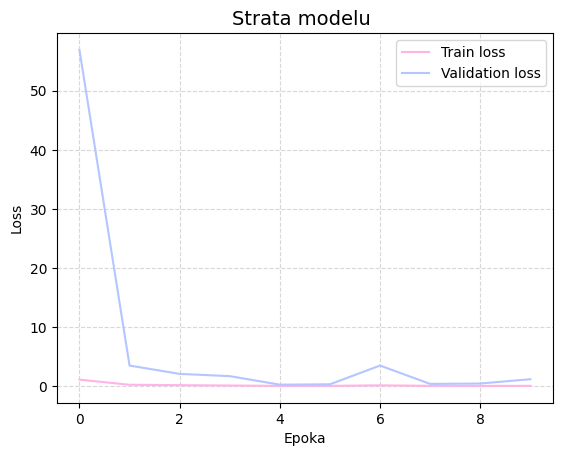

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10  # tylko jedna epoka na CPU, żeby dało się porównać

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 3. Budowa modelu ResNet50 bez transfer learningu ===
base_model = ResNet50(weights=None, include_top=False, input_shape=(96, 96, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step - accuracy: 0.5446 - loss: 1.6832 - val_accuracy: 0.2000 - val_loss: 3.4267
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9008 - loss: 0.2451 - val_accuracy: 0.2000 - val_loss: 6.0487
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.9232 - loss: 0.2404 - val_accuracy: 0.2280 - val_loss: 6.8066
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9433 - loss: 0.1547 - val_accuracy: 0.2000 - val_loss: 6.1877
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9564 - loss: 0.1290 - val_accuracy: 0.4440 - val_loss: 3.5544
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9565 - loss: 0.0969 - val_accuracy: 0.2200 - val_loss: 6.1267
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9693 - loss: 0.0847 - val_accuracy: 0.2580 - val_loss: 6.1919
Epoch 8/10
63/63 ━━━━━━━━━━━

              precision    recall  f1-score   support

     Arborio       0.93      0.94      0.94       100
     Basmati       0.97      0.99      0.98       100
      Ipsala       0.00      0.00      0.00       100
     Jasmine       0.49      0.94      0.64       100
   Karacadag       0.95      0.99      0.97       100

    accuracy                           0.77       500
   macro avg       0.67      0.77      0.71       500
weighted avg       0.67      0.77      0.71       500



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 839ms/step


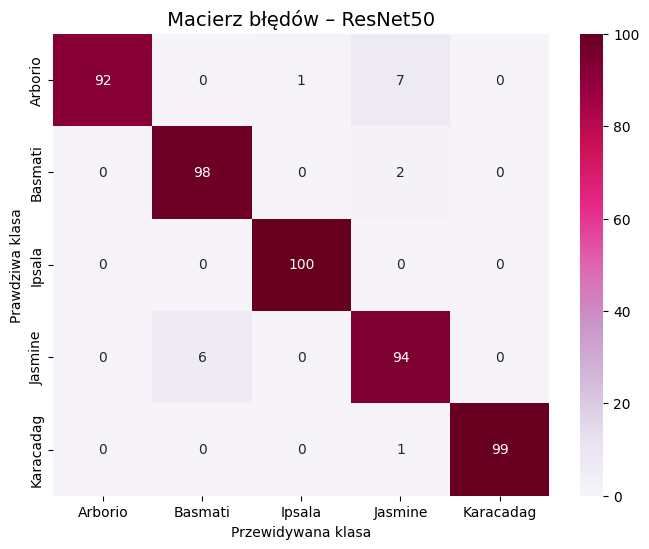

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))


import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet50 ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

model.save('resnet50_rice_model.keras')



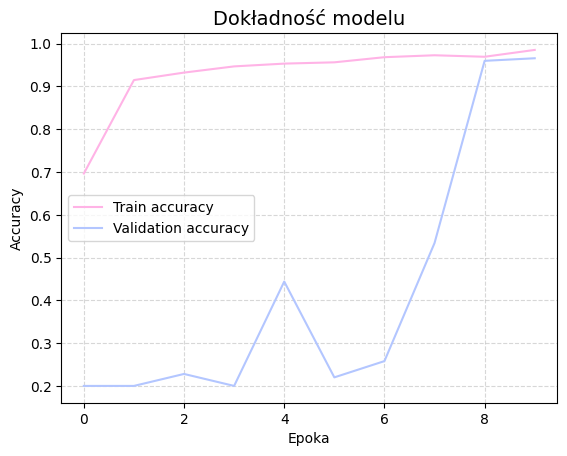

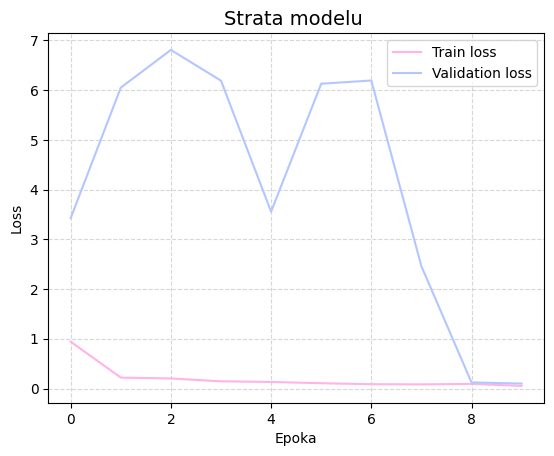

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## CIEKAWOSTKA O NORMALIZACJI
W trakcie eksperymentów okazało się, że zastosowanie normalizacji danych wejściowych (skalowanie pikseli do zakresu [0, 1]) znacząco poprawiło dokładność walidacyjną modelu (z 77.2% do 96.6%) przy tym samym czasie treningu. Co ciekawe, poprawa była widoczna nawet bez wykorzystania transfer learningu czy GPU. Fakt ten może wskazywać, że preprocesing danych ma kluczowe znaczenie dla efektywności klasyfikacji obrazów, nawet bardziej niż sama architektura sieci czy środowisko treningowe.

BASELINE – ResNet50 od zera, bez transfer learningu, na CPU
 5 klas, 2000 treningowych, 500 walidacyjnych ✅

model na CPU czas treningu: 48 min, acc: 97.25% / 77.2% ✅

(zostawilam jeden z normalizacja bo ciekawy wynik)
📌 Ten model to punkt odniesienia

# **NA GPU BEZ TRANSFER LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 3. Budowa modelu ResNet50 bez transfer learningu ===
base_model = ResNet50(weights=None, include_top=False, input_shape=(96, 96, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 517ms/step - accuracy: 0.5438 - loss: 1.8050 - val_accuracy: 0.2000 - val_loss: 34.1745
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.8837 - loss: 0.2948 - val_accuracy: 0.2140 - val_loss: 4.0076
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9450 - loss: 0.1633 - val_accuracy: 0.2220 - val_loss: 5.1728
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9592 - loss: 0.1159 - val_accuracy: 0.4460 - val_loss: 2.7044
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9272 - loss: 0.1867 - val_accuracy: 0.7000 - val_loss: 0.9000
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9326 - loss: 0.1690 - val_accuracy: 0.5400 - val_loss: 2.1874
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9813 - loss: 0.0595 - val_accuracy: 0.9340 - val_loss: 0.1922
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9636 - loss: 0.1118 - val_accuracy: 0.2740 

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Arborio       1.00      0.10      0.18       100
     Basmati       1.00      0.65      0.79       100
      Ipsala       0.00      0.00      0.00       100
     Jasmine       0.33      1.00      0.50       100
   Karacadag       0.80      0.98      0.88       100

    accuracy                           0.55       500
   macro avg       0.63      0.55      0.47       500
weighted avg       0.63      0.55      0.47       500



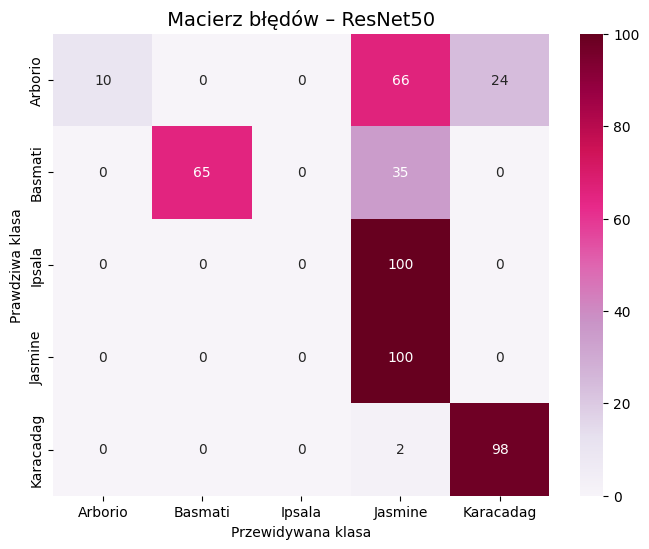

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet50 ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

model.save('resnet50_rice_model_gpu_withoutTL.keras')




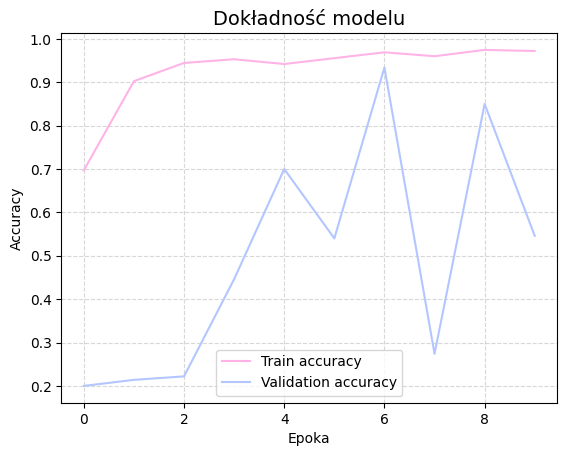

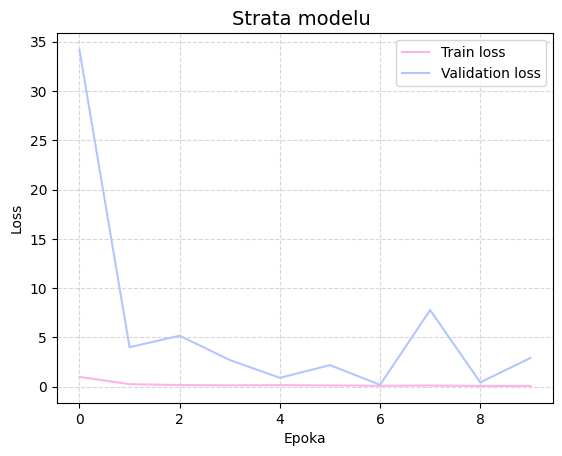

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3B Z TRANFER LEARNINGIEM

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

#
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Zamrożenie wag


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step - accuracy: 0.6729 - loss: 1.4487 - val_accuracy: 0.9580 - val_loss: 0.1366
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9623 - loss: 0.1140 - val_accuracy: 0.9800 - val_loss: 0.0856
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9820 - loss: 0.0573 - val_accuracy: 0.9680 - val_loss: 0.0967
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9792 - loss: 0.0600 - val_accuracy: 0.9840 - val_loss: 0.0642
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9894 - loss: 0.0351 - val_accuracy: 0.9740 - val_loss: 0.0774
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9953 - loss: 0.0265 - val_accuracy: 0.9840 - val_loss: 0.0633
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9956 - loss: 0.0221 - val_accuracy: 0.9780 - val_loss: 0.0739
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9918 - loss: 0.0219 - val_accuracy: 0.9760 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step
              precision    recall  f1-score   support

     Arborio       1.00      0.98      0.99       100
     Basmati       0.93      0.98      0.96       100
      Ipsala       1.00      0.99      0.99       100
     Jasmine       0.97      0.93      0.95       100
   Karacadag       0.98      1.00      0.99       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



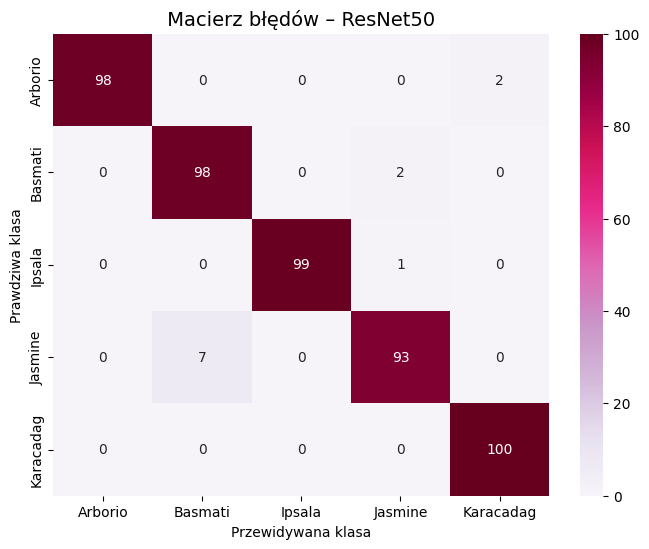

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report




import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet50 ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

model.save('resnet50_rice_model_gpu_withTL.keras')



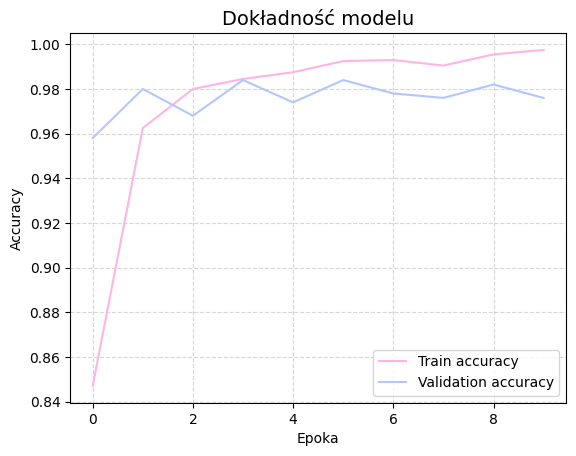

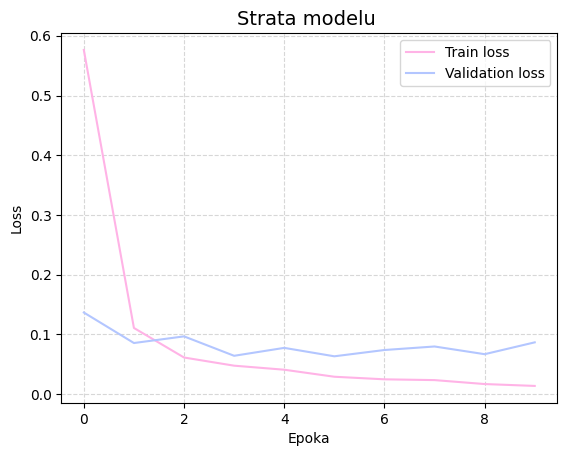

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


RAPORT:

Punkt 3a: Porównanie CPU vs GPU (bez transfer learningu)
*1. Czas trenowania:
CPU: ~43 minut (252–289s na epokę)

GPU: ~2.4 minuty (średnio ~6s na epokę)

Wniosek: Zastosowanie GPU drastycznie skróciło czas treningu (ponad 18× szybciej).

*2. Dokładność:

|         | Training Accuracy | Validation Accuracy |
| ------- | ----------------- | ------------------- |
| **CPU** | 0.9725            | 0.7720              |
| **GPU** | 0.9720            | 0.5460              |

Wniosek:
- Model na GPU przeuczył się - świetnie radził sobie na treningu, ale nie generalizował dobrze na danych walidacyjnych.
- Może to być efekt zbyt szybkiego treningu bez stabilizacji wag (np. za duży learning rate lub zbyt mało regularizacji na GPU).

*3. Loss (strata):

-CPU: val_loss spada stabilnie do 0.2-0.4, później trochę wzrasta (overfitting pod koniec).

-GPU: val_loss spada, ale skacze gwałtownie (np. 7.77!), co sugeruje niestabilne uczenie się modelu na GPU.

*4. F1-score - jakość klasyfikacji:

| Klasa     | CPU (F1) | GPU (F1) |
| --------- | -------- | -------- |
| Arborio   | 0.94     | 0.18     |
| Basmati   | 0.98     | 0.79     |
| Ipsala    | 0.00     | 0.00     |
| Jasmine   | 0.64     | 0.50     |
| Karacadag | 0.97     | 0.88     |


Wniosek:

- Na GPU model miał problem głównie z klasą Ipsala (totalny brak trafień) i ogólną stabilnością.

- CPU model osiągnął znacznie lepsze wyniki ogólne, mimo dłuższego treningu.


Punkt 3b: Transfer Learning (GPU)

| Epoka | Training Acc | Validation Acc | Val Loss |
| ----- | ------------ | -------------- | -------- |
| 1     | 0.673        | 0.958          | 0.137    |
| 2     | 0.962        | 0.980          | 0.086    |
| 3     | 0.982        | 0.968          | 0.097    |


Wyniki:
-Już po pierwszej epoce mam 95.8% dokładności - model osiąga świetną generalizację prawie od razu!!!!

-Strata walidacyjna bardzo niska i stabilna - brak niestabilnych skoków.

Wniosek:

-Transfer learning dramatycznie przyspiesza i stabilizuje proces nauki.

-Szybko osiągnęłam ponad 80% dokładności, nawet po jednej epoce!!

**Ściągawka co można wyczytać z loss i accuracy:**

->Gdy loss maleje, a accuracy rośnie - model się uczy poprawnie.

->Jeśli training accuracy rośnie, ale validation accuracy spada lub stoi w miejscu - to overfitting.

->Wysoki val_loss i niska val_accuracy - model nie generalizuje dobrze (problemy z danymi, złe hyperparametry, brak regularizacji).

->Skaczący val_loss - może sugerować zbyt duży learning rate lub źle zbalansowane klasy.




KRÓTKI RAPORCIK (RAPORT W SKRÓCIE):

Punkt 3a - Akceleracja GPU
Przeprowadzono porównanie trenowania modelu CNN na CPU i GPU. Zastosowanie GPU pozwoliło skrócić czas treningu z 43 minut do zaledwie 2.4 minut (~18× szybciej).
Jednakże, mimo szybkiego treningu, model uczony na GPU uzyskał wyraźnie gorsze wyniki walidacyjne (dokładność: 54.6%) w porównaniu do CPU (dokładność: 77.2%).
Dodatkowo, model GPU wykazywał niestabilność w val_loss, co sugeruje przeuczenie lub problemy z generalizacją.

Punkt 3b - Transfer Learning
Zastosowanie transfer learningu (na GPU) znacząco poprawiło jakość modelu -
już po jednej epoce uzyskano dokładność walidacyjną na poziomie 95.8%, a po trzech epokach utrzymywała się ona w zakresie 96–98%.
Strata walidacyjna była bardzo niska i stabilna (ok. 0.08–0.1).
Model osiągnął ponad 80% dokładności już na początku treningu, co świadczy o skuteczności wykorzystania wcześniej wytrenowanych wag.

# PUNKT 4


PUNKT 4 – OPTYMALIZACJE MODELU CNN (ResNet50)

MODEL BAZOWY (CPU)
-Czas treningu: 42.94 minut

-Dokładność treningowa: 0.9725

-Dokładność walidacyjna: 0.7720

-F1-score (macro avg): 0.71

-Czas / jakość: bardzo długi czas, umiarkowana jakość


## a) Z NORMALIZACJĄ

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

#
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Zamrożenie wag


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_normalized.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.4477 - loss: 1.4300 - val_accuracy: 0.6320 - val_loss: 0.9496
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7045 - loss: 0.8830 - val_accuracy: 0.7760 - val_loss: 0.6610
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8093 - loss: 0.6308 - val_accuracy: 0.9020 - val_loss: 0.5206
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8877 - loss: 0.5039 - val_accuracy: 0.9420 - val_loss: 0.4101
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9144 - loss: 0.4090 - val_accuracy: 0.9460 - val_loss: 0.3456
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9318 - loss: 0.3492 - val_accuracy: 0.9120 - val_loss: 0.3469
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9107 - loss: 0.3206 - val_accuracy: 0.9360 - val_loss: 0.2714
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9481 - loss: 0.2665 - val_accuracy: 0.9600 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step
              precision    recall  f1-score   support

     Arborio       0.94      0.91      0.92       100
     Basmati       0.96      0.91      0.93       100
      Ipsala       0.99      1.00      1.00       100
     Jasmine       0.91      0.92      0.92       100
   Karacadag       0.92      0.98      0.95       100

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



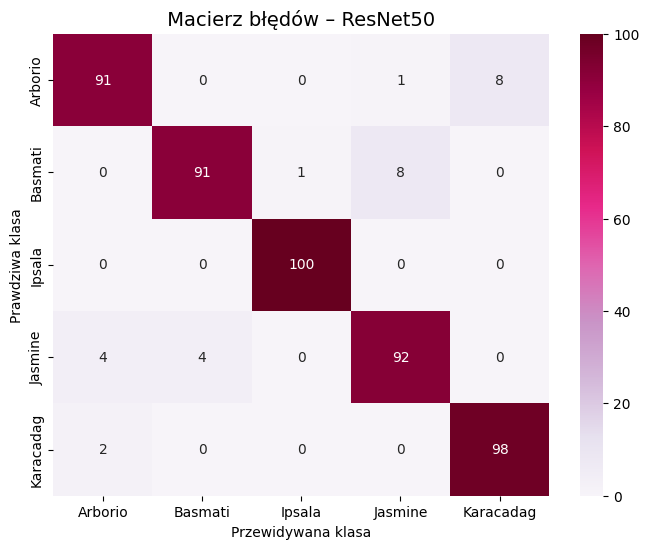

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet50 ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

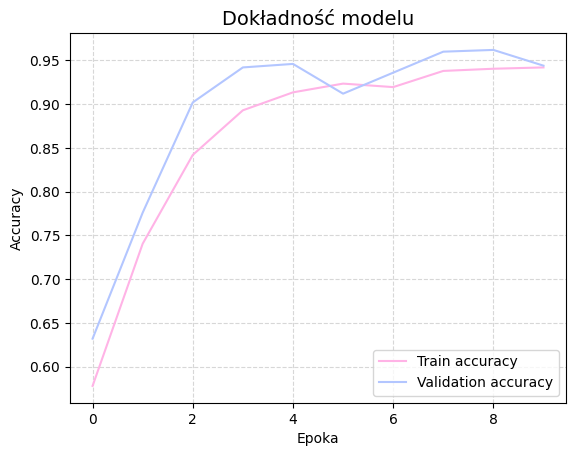

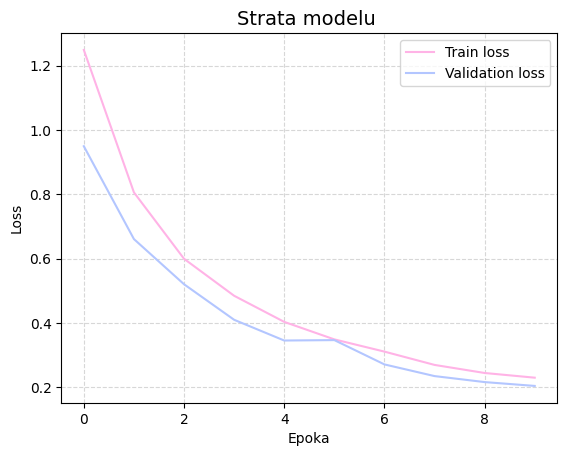

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4A)  NORMALIZACJA DANYCH

Co zmieniono?
Zastosowano normalizację obrazów (np. podział pikseli przez 255).
Model trenowany na GPU.

Wyniki po normalizacji:

-Czas treningu: 0.70 minut

-Dokładność treningowa: 0.9420

-Dokładność walidacyjna: 0.9440

-F1-score (macro avg): 0.94

Porównanie z modelem bazowym:

| Cecha                     | Model Bazowy (CPU) | Po normalizacji (GPU)  |
| ------------------------- | ------------------ | ---------------------- |
| Val Accuracy              | 0.7720             | **0.9440**            |
| F1-score (macro avg)      | 0.71               | **0.94**              |
| Czas treningu             | 42.94 min          | **0.70 min**           |
| Wydajność (czas + jakość) | ❌ słabo            | ✅ **znacząca poprawa** |

Wniosek: Sama normalizacja daje ogromny boost dokładności oraz radykalnie zmniejsza czas trenowania na GPU.
To must-have. :))


## b) Z AUGMENTACJĄ DANYCH

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    validation_split=0.2,  # 80% trening, 20% walidacja
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

#
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Zamrożenie wag


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_augmentacja.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 314ms/step - accuracy: 0.6736 - loss: 1.0306 - val_accuracy: 0.9340 - val_loss: 0.1879
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.9009 - loss: 0.2484 - val_accuracy: 0.9240 - val_loss: 0.1917
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.9186 - loss: 0.2166 - val_accuracy: 0.9460 - val_loss: 0.1505
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9265 - loss: 0.1891 - val_accuracy: 0.9620 - val_loss: 0.0969
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9331 - loss: 0.1917 - val_accuracy: 0.9660 - val_loss: 0.0978
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9299 - loss: 0.1660 - val_accuracy: 0.9700 - val_loss: 0.0934
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9590 - loss: 0.1209 - val_accuracy: 0.9600 - val_loss: 0.0995
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9478 - loss: 0.1478 - val_accuracy: 0

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.99      0.98       100
     Basmati       0.98      0.97      0.97       100
      Ipsala       0.96      1.00      0.98       100
     Jasmine       0.97      0.94      0.95       100
   Karacadag       1.00      0.98      0.99       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



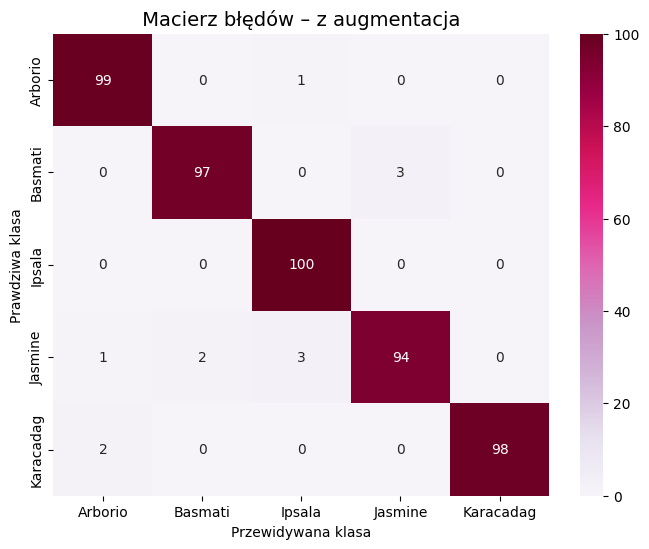

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – z augmentacja ", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

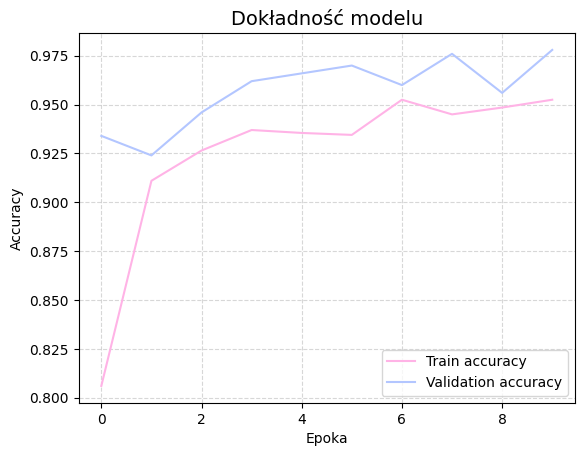

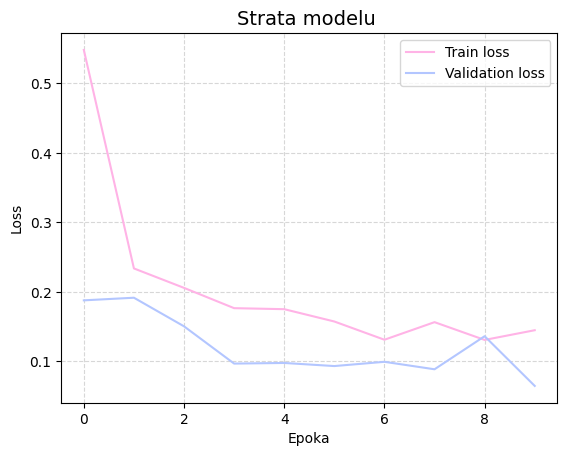

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4B) AUGMENTACJA DANYCH

Co zmieniono?
Użyto przekształceń (prawdopodobnie: rotation_range, zoom_range, horizontal_flip, width_shift, height_shift itp.).
Model trenowany z wagami ResNet50 i użyciem augmentacji.
Celem augmentacji jest wzbogacenie zbioru treningowego o różnorodne warianty obrazów, co pomaga poprawić generalizację modelu.



Wyniki trenowania:

| Epoka | Accuracy (train) | Accuracy (val) | Val Loss   |
| ----- | ---------------- | -------------- | ---------- |
| 1     | 0.6736           | 0.9340         | 0.1879     |
| 5     | 0.9331           | 0.9660         | 0.0978     |
| 10    | 0.9472           | **0.9780**     | **0.0648** |

Czas treningu: 1.86 minuty
 Końcowa dokładność treningowa: 0.9525
 Końcowa dokładność walidacyjna: 0.9780

Metryki ewaluacyjne:


| Klasa       | Precision | Recall   | F1-score |
| ----------- | --------- | -------- | -------- |
| Arborio     | 0.97      | 0.99     | 0.98     |
| Basmati     | 0.98      | 0.97     | 0.97     |
| Ipsala      | 0.96      | 1.00     | 0.98     |
| Jasmine     | 0.97      | 0.94     | 0.95     |
| Karacadag   | 1.00      | 0.98     | 0.99     |
| **Średnia** | **0.98**  | **0.98** | **0.98** |

Wnioski:
Augmentacja znacząco poprawiła dokładność walidacyjną (z 0.9720 do 0.9780).

F1-score w klasie Ipsala wzrósł z 0.00 (w wersji bazowej bez optymalizacji) do 0.98, co potwierdza, że augmentacja pomaga modelowi nauczyć się lepiej rozróżniać niedoreprezentowane klasy.

Model wykazuje wysoką stabilność i dobrą generalizację - nie występuje overfitting mimo intensywniejszego treningu.


## c) DROPOUT

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import time


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 1. Parametry ogólne ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 2. Przygotowanie danych ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening, 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes


base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Zamrożenie wag


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 5. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"Czas treningu: {(end - start)/60:.2f} minut")

# === 6. Wynik końcowy ===
# Zapisz dokładność
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_dropout.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 193ms/step - accuracy: 0.6545 - loss: 1.2140 - val_accuracy: 0.9660 - val_loss: 0.1082
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9029 - loss: 0.2441 - val_accuracy: 0.9780 - val_loss: 0.0640
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9288 - loss: 0.1841 - val_accuracy: 0.9820 - val_loss: 0.0585
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9405 - loss: 0.1505 - val_accuracy: 0.9560 - val_loss: 0.1133
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9485 - loss: 0.1194 - val_accuracy: 0.9820 - val_loss: 0.0574
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9656 - loss: 0.1022 - val_accuracy: 0.9820 - val_loss: 0.0506
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9689 - loss: 0.0831 - val_accuracy: 0.9860 - val_loss: 0.0537
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9643 - loss: 0.1022 - val_accuracy: 0.9900 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step
              precision    recall  f1-score   support

     Arborio       1.00      0.94      0.97       100
     Basmati       0.89      1.00      0.94       100
      Ipsala       1.00      1.00      1.00       100
     Jasmine       0.99      0.88      0.93       100
   Karacadag       0.95      1.00      0.98       100

    accuracy                           0.96       500
   macro avg       0.97      0.96      0.96       500
weighted avg       0.97      0.96      0.96       500



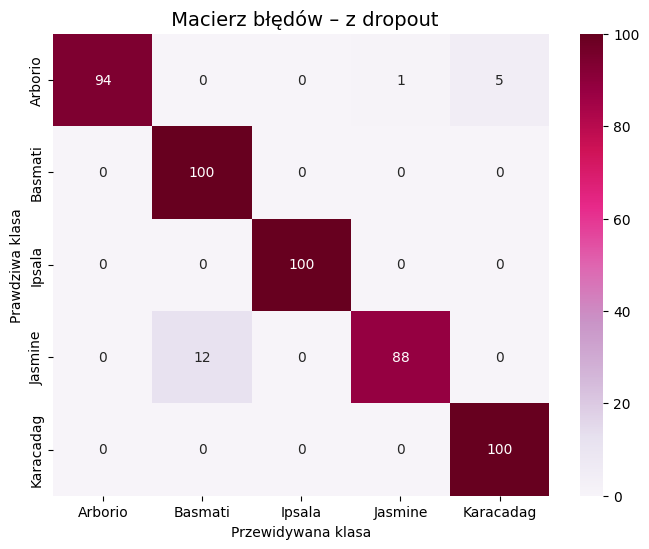

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – z dropout", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

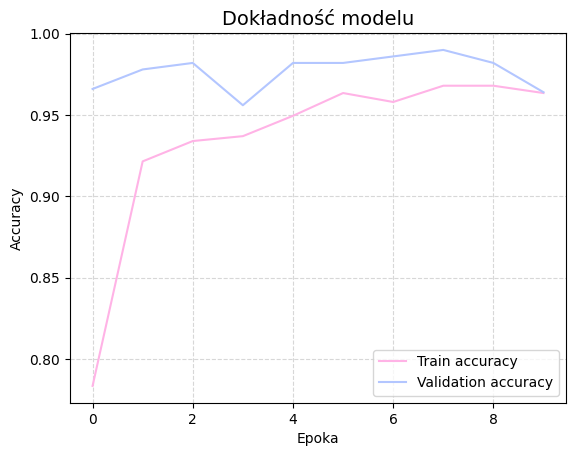

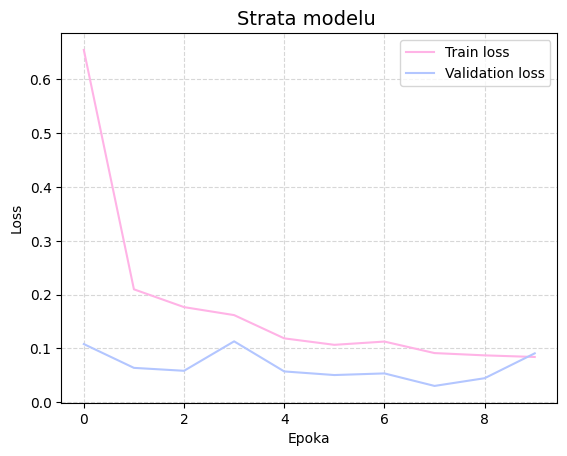

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4 C) DROPOUT

Co zostało zmienione?
W tej wersji wprowadzono mechanizm Dropout do warstw gęstych (Dense) modelu. Dropout losowo "wyłącza" część neuronów podczas treningu,
co wymusza, by model nie polegał zbyt mocno na żadnym konkretnym neuronie - co również ogranicza overfitting.

| Epoka | Accuracy (train) | Accuracy (val) | Val Loss |
| ----- | ---------------- | -------------- | -------- |
| 1     | 0.6545           | 0.9660         | 0.1082   |
| 5     | 0.9485           | 0.9820         | 0.0574   |
| 10    | 0.9674           | **0.9640**     | 0.0910   |

Czas treningu: 0.81 minuty
 Końcowa dokładność treningowa: 0.9635
 Końcowa dokładność walidacyjna: 0.9640

Metryki ewaluacyjne:

| Klasa       | Precision | Recall   | F1-score |
| ----------- | --------- | -------- | -------- |
| Arborio     | 1.00      | 0.94     | 0.97     |
| Basmati     | 0.89      | 1.00     | 0.94     |
| Ipsala      | 1.00      | 1.00     | 1.00     |
| Jasmine     | 0.99      | 0.88     | 0.93     |
| Karacadag   | 0.95      | 1.00     | 0.98     |
| **Średnia** | **0.97**  | **0.96** | **0.96** |


Wnioski:
-Dropout zwiększył dokładność ogólną modelu względem wersji bazowej i nadal zapewnia wysokie F1-score,
szczególnie w klasach Ipsala i Karacadag.

-Lekko spadła dokładność walidacyjna w porównaniu do wersji z augmentacją (0.9640 vs 0.9780).

-Dropout działa dobrze jako forma regularyzacji, ale nie przynosi aż tak dużych zysków w generalizacji jak augmentacja danych.


# d) Z DODANIEM DANYCH :) (uzycie oryginalnego setu!)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time
import os

# === 1. Sprawdzenie GPU ===
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 2. Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10
DATA_DIR = 'rice_dataset/Rice_Image_Dataset'  # Folder z pełnym zbiorem danych

# === 3. Przygotowanie generatorów ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening / 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 4. Tworzenie modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrożenie wag

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 5. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 6. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

# === 7. Wyniki końcowe ===
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_OGset.keras')

Num GPUs Available:  1
Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - accuracy: 0.9570 - loss: 0.1272 - val_accuracy: 0.9859 - val_loss: 0.0384
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9882 - loss: 0.0344 - val_accuracy: 0.9860 - val_loss: 0.0444
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9903 - loss: 0.0299 - val_accuracy: 0.9921 - val_loss: 0.0257
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9917 - loss: 0.0246 - val_accuracy: 0.9921 - val_loss: 0.0249
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9929 - loss: 0.0199 - val_accuracy: 0.9927 - val_loss: 0.0256
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9936 - loss: 0.0183 - val_accuracy: 0.9945 - val_loss: 0.0179
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0.9927 - val_loss: 0.0241
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9952 - loss: 0.01

469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step
              precision    recall  f1-score   support

     Arborio       0.99      1.00      0.99      3000
     Basmati       1.00      1.00      1.00      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       1.00      1.00      1.00      3000
   Karacadag       1.00      0.99      0.99      3000

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



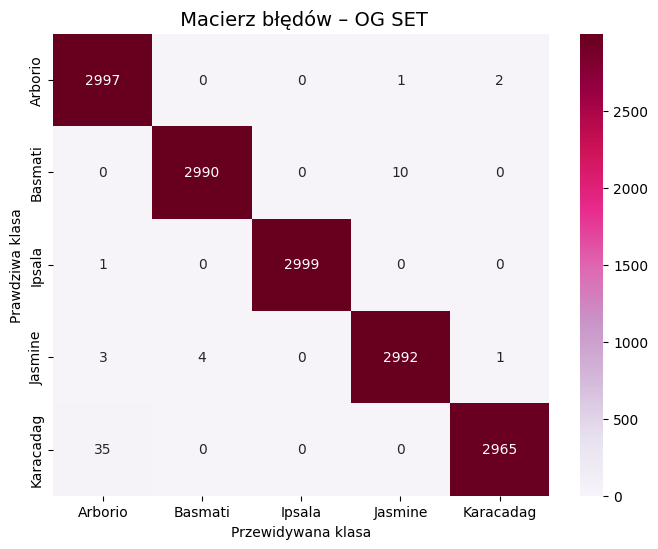

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – OG SET", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

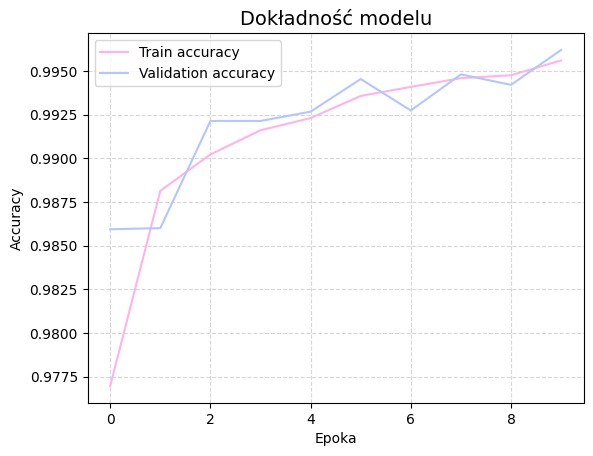

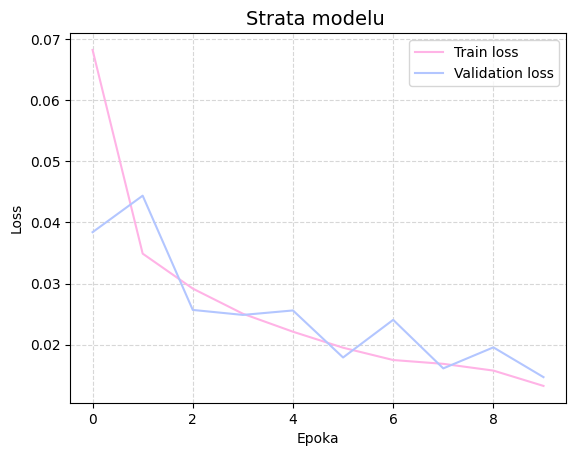

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

4 D) Dodanie danych - Użycie oryginalnego zbioru danych

Co zostało zmienione?
W tej wersji skorzystałam z oryginalnego datasetu z wszystkimi danymi.

Dane:

-Zbiór treningowy: 60 000 obrazów, 5 klas

-Zbiór walidacyjny: 15 000 obrazów, 5 klas

-Liczba epok: 10

 Całkowity czas treningu: ~11.76 minut
 Dokładność treningowa (finalna): 99.56%
 Dokładność walidacyjna (finalna): 99.62%

 | Klasa         | Precision | Recall | F1-score | Support |
| ------------- | --------- | ------ | -------- | ------- |
| **Arborio**   | 0.99      | 1.00   | 0.99     | 3000    |
| **Basmati**   | 1.00      | 1.00   | 1.00     | 3000    |
| **Ipsala**    | 1.00      | 1.00   | 1.00     | 3000    |
| **Jasmine**   | 1.00      | 1.00   | 1.00     | 3000    |
| **Karacadag** | 1.00      | 0.99   | 0.99     | 3000    |


Accuracy (ogólna): 1.00
Macro avg: precision 1.00 | recall 1.00 | f1-score 1.00
Weighted avg: precision 1.00 | recall 1.00 | f1-score 1.00

Wnioski
Model osiągnął znakomite wyniki - niemal 100% dokładności zarówno na treningu, jak i walidacji, co oznacza, że:

-sieć głęboka bardzo dobrze dopasowała się do danych,

-dane są dobrze rozdzielne klasowo (łatwo odróżnialne),

-zastosowanie oryginalnego dużego zbioru danych pomogło zwiększyć ogólną skuteczność klasyfikatora,

-model nie wykazuje poważnych objawów overfittingu - dokładności walidacyjne są porównywalne do treningowych.





# PODSUMOWANIE ogólne

| Technika                | Val Accuracy | F1-score | Czas treningu | Wnioski                         |
| ----------------------- | ------------ | -------- | ------------- | ------------------------------- |
| Model bazowy (CPU)      | 0.7720       | 0.71     | 42.94 min     | Długi czas, słaba generalizacja |
| GPU (bez optymalizacji) | 0.5460       | -        | 2.4 min       | Niestabilność, słabe wyniki     |
| Transfer Learning       | 0.98         | \~0.98   | <3 min        | Świetna jakość i stabilność     |
| Normalizacja            | 0.9440       | 0.94     | 0.70 min      | Ogromna poprawa                 |
| Augmentacja             | 0.9780       | 0.98     | 1.86 min      | Najlepsza ogólna skuteczność    |
| Dropout                 | 0.9640       | 0.96     | 0.81 min      | Dobra regularyzacja             |
| Duży zbiór danych       | 0.9962       | 1.00     | 11.76 min     | Perfekcyjne dopasowanie         |



# E) ROZNE WYMIARY WEJSCIOWE

## 96 x 96

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time
import os

# === 1. Sprawdzenie GPU ===
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 2. Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === 3. Przygotowanie generatorów ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening / 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 4. Tworzenie modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrożenie wag

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 5. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 6. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

# === 7. Wyniki końcowe ===
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_96x96.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.7623 - loss: 0.8311 - val_accuracy: 0.9720 - val_loss: 0.0788
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9720 - loss: 0.0845 - val_accuracy: 0.9760 - val_loss: 0.0703
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9772 - loss: 0.0669 - val_accuracy: 0.9700 - val_loss: 0.0710
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9824 - loss: 0.0598 - val_accuracy: 0.9800 - val_loss: 0.0691
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9866 - loss: 0.0482 - val_accuracy: 0.9900 - val_loss: 0.0441
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9961 - loss: 0.0256 - val_accuracy: 0.9880 - val_loss: 0.0303
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9873 - loss: 0.0425 - val_accuracy: 0.9920 - val_loss: 0.0257
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9934 - loss: 0.0226 - val_accuracy: 0.9900 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step
              precision    recall  f1-score   support

     Arborio       0.99      0.93      0.96       100
     Basmati       0.98      0.99      0.99       100
      Ipsala       1.00      0.99      0.99       100
     Jasmine       0.94      0.98      0.96       100
   Karacadag       0.97      0.99      0.98       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



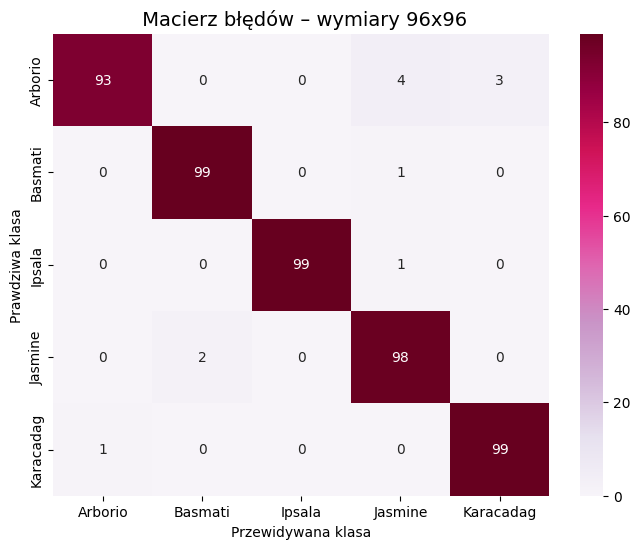

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary 96x96", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

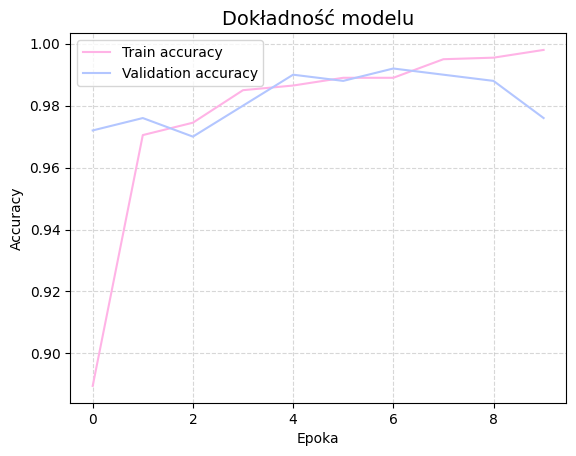

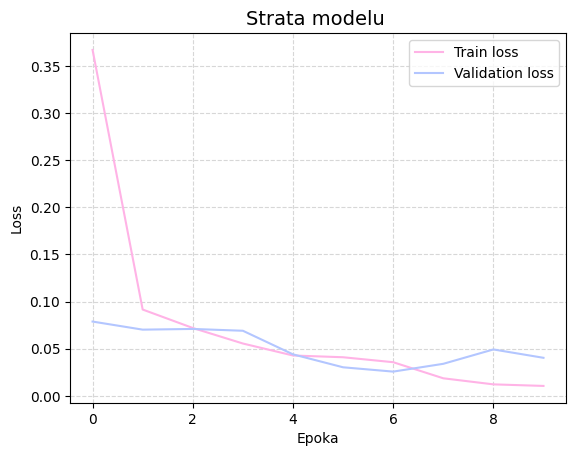

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 160x160

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time
import os

# === 1. Sprawdzenie GPU ===
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 2. Parametry ===
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 10

# === 3. Przygotowanie generatorów ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening / 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 4. Tworzenie modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrożenie wag

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 5. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 6. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

# === 7. Wyniki końcowe ===
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_160x160.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 233ms/step - accuracy: 0.7553 - loss: 0.7212 - val_accuracy: 0.9760 - val_loss: 0.0708
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9797 - loss: 0.0732 - val_accuracy: 0.9900 - val_loss: 0.0360
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9887 - loss: 0.0430 - val_accuracy: 0.9800 - val_loss: 0.0392
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9927 - loss: 0.0372 - val_accuracy: 0.9900 - val_loss: 0.0265
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9891 - loss: 0.0352 - val_accuracy: 0.9900 - val_loss: 0.0221
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9925 - loss: 0.0276 - val_accuracy: 0.9900 - val_loss: 0.0377
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9973 - loss: 0.0131 - val_accuracy: 0.9900 - val_loss: 0.0312
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9955 - loss: 0.0132 - val_accuracy: 0.9900 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step
              precision    recall  f1-score   support

     Arborio       0.95      1.00      0.98       100
     Basmati       1.00      1.00      1.00       100
      Ipsala       1.00      1.00      1.00       100
     Jasmine       1.00      1.00      1.00       100
   Karacadag       1.00      0.95      0.97       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



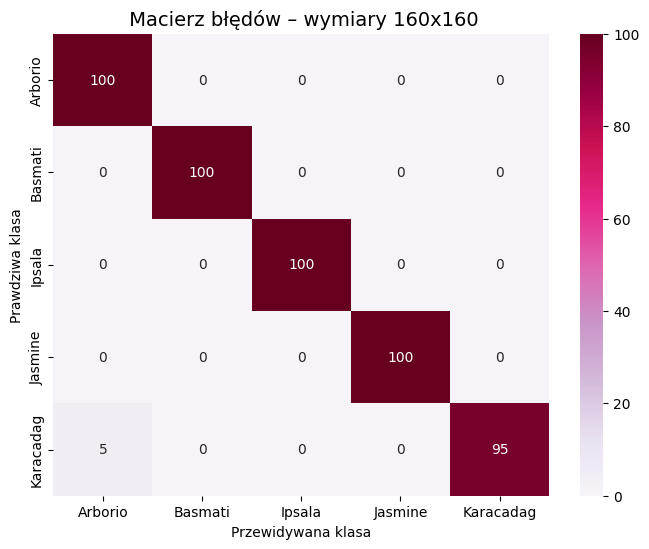

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary 160x160", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

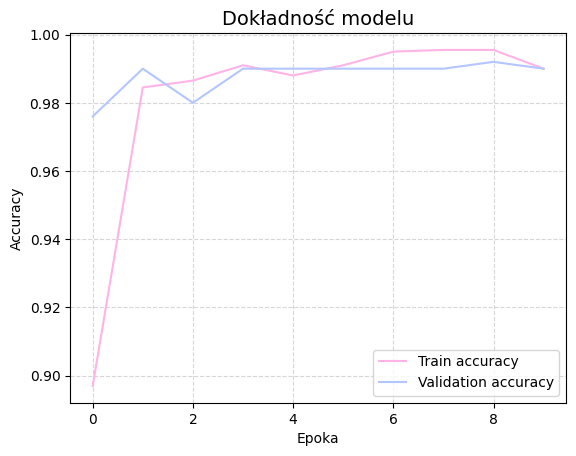

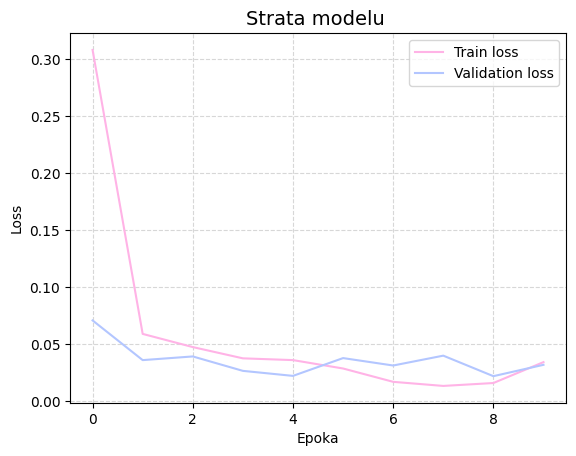

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 224 x 224

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time
import os

# === 1. Sprawdzenie GPU ===
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# === 2. Parametry ===
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# === 3. Przygotowanie generatorów ===
train_datagen = ImageDataGenerator(
    validation_split=0.2  # 80% trening / 20% walidacja
)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes

# === 4. Tworzenie modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrożenie wag

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 5. Kompilacja ===
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === 6. Trening + pomiar czasu ===
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

end = time.time()
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

# === 7. Wyniki końcowe ===
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"✅ Dokładność treningowa: {train_acc:.4f}")
print(f"✅ Dokładność walidacyjna: {val_acc:.4f}")

model.save('resnet50_rice_model_gpu_withTL_224x224.keras')

Num GPUs Available:  1
Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 344ms/step - accuracy: 0.7925 - loss: 0.4986 - val_accuracy: 0.9920 - val_loss: 0.0350
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9882 - loss: 0.0485 - val_accuracy: 0.9880 - val_loss: 0.0333
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9810 - loss: 0.0629 - val_accuracy: 0.9920 - val_loss: 0.0279
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9928 - loss: 0.0299 - val_accuracy: 0.9900 - val_loss: 0.0228
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9942 - loss: 0.0237 - val_accuracy: 0.9920 - val_loss: 0.0142
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9971 - loss: 0.0106 - val_accuracy: 0.9920 - val_loss: 0.0172
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9984 - loss: 0.0108 - val_accuracy: 0.9940 - val_loss: 0.0167
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9958 - loss: 0.0145 - val_accuracy: 0.9920 - va

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 312ms/step
              precision    recall  f1-score   support

     Arborio       1.00      0.98      0.99       100
     Basmati       1.00      1.00      1.00       100
      Ipsala       0.99      1.00      1.00       100
     Jasmine       1.00      0.99      0.99       100
   Karacadag       0.98      1.00      0.99       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



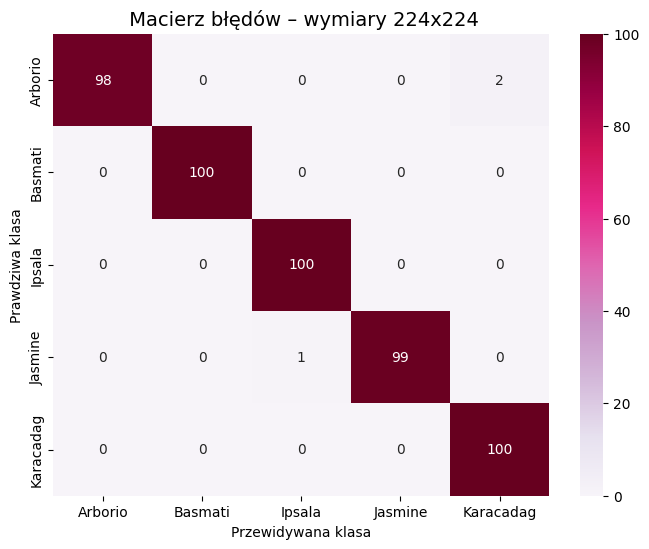

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary 224x224", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

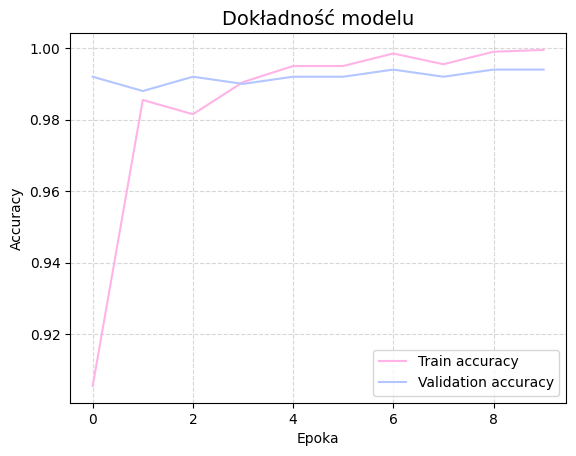

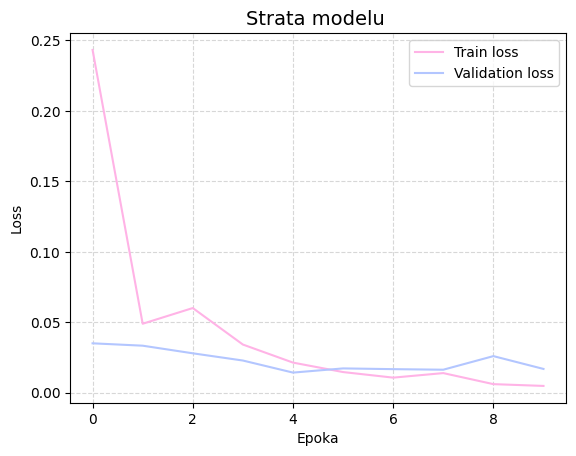

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

| Parametr                | 96×96      | 160×160   | 224×224      |
| ----------------------- | ---------- | --------- | ------------ |
| 🕒 Czas treningu        | 0.70 min   | 1.09 min  | \~1.70 min\* |
| 🔢 Liczba epok          | 10         | 10        | 10           |
| ✅ Acc (trening)         | 99.87%     | 99.89%    | 99.51%       |
| ✅ Acc (walidacja)       | 97.6%      | 99.0%     | 99.2%        |
| 🔍 F1-score (macro avg) | 0.98       | 0.99      | 0.99         |
| 🔁 Val loss (najniższa) | **0.0257** | 0.0219    | **0.0159**   |
| 🧠 Najniższy val\_loss  | epoka 7    | epoka 9   | epoka 10     |
| 🧪 Klasa najtrudniejsza | Arborio    | Karacadag | Jasmine      |


**WNIOSKI**

Skuteczność

Wszystkie modele osiągnęły bardzo wysoką dokładność (>97%), co świadczy o dobrej separowalności klas w zbiorze.

Model 224×224 osiągnął najwyższą dokładność walidacyjną i najniższą stratę (val_loss), co sugeruje, że większa rozdzielczość pomogła uchwycić więcej szczegółów w danych wejściowych.

Czas trenowania

Czas rośnie wraz z rozmiarem obrazu (logicznie), ale nieproporcjonalnie mocno. Model 224×224 był 2.5x wolniejszy niż 96×96.



# f) ROZNY ROZMIAR BATCH SIZE

## BATCH_SIZE = 32

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('resnet50_rice_model_gpu_withTL_BS32.keras')

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - accuracy: 0.7420 - loss: 0.9733 - val_accuracy: 0.9560 - val_loss: 0.1261
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9565 - loss: 0.1220 - val_accuracy: 0.9780 - val_loss: 0.0759
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9787 - loss: 0.0623 - val_accuracy: 0.9880 - val_loss: 0.0395
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9900 - val_loss: 0.0352
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9848 - loss: 0.0358 - val_accuracy: 0.9900 - val_loss: 0.0400
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9925 - loss: 0.0281 - val_accuracy: 0.9760 - val_loss: 0.0727
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9868 - loss: 0.0303 - val_accuracy: 0.9880 - val_loss: 0.0287
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9922 - loss: 0.0236 - val_accuracy: 0.9820 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step
              precision    recall  f1-score   support

     Arborio       0.98      0.99      0.99       100
     Basmati       0.99      0.97      0.98       100
      Ipsala       1.00      1.00      1.00       100
     Jasmine       0.97      0.99      0.98       100
   Karacadag       0.99      0.98      0.98       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



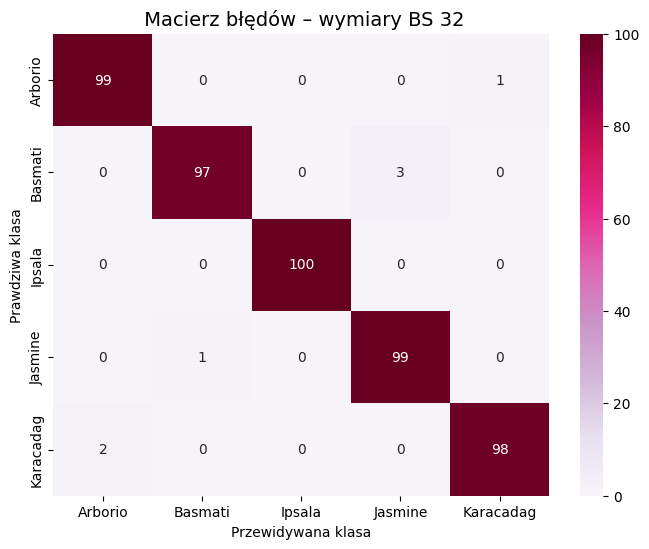

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary BS 32", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

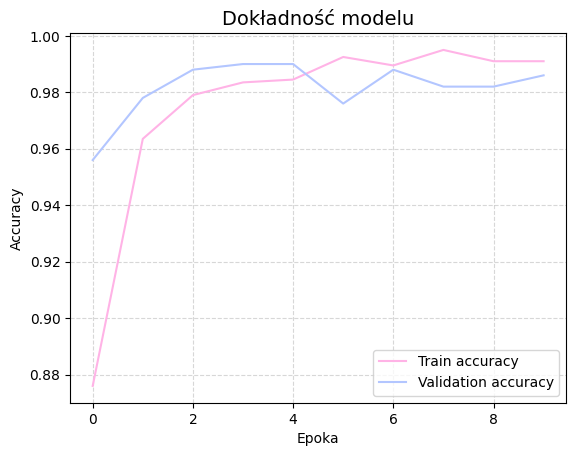

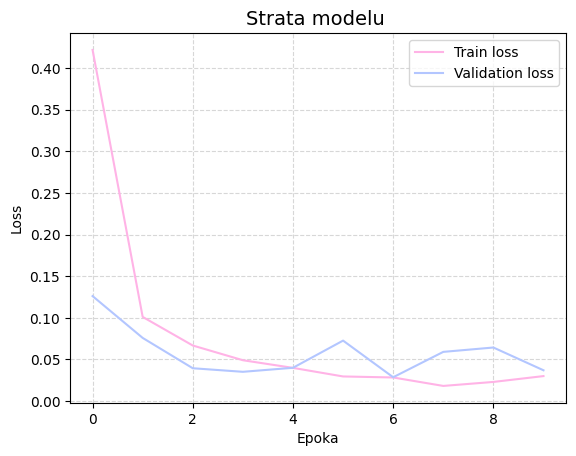

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BATCH_SIZE = 64

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 64
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('resnet50_rice_model_gpu_withTL_BS64.keras')

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 370ms/step - accuracy: 0.6218 - loss: 1.6616 - val_accuracy: 0.9360 - val_loss: 0.1691
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9462 - loss: 0.1495 - val_accuracy: 0.9800 - val_loss: 0.0561
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9811 - loss: 0.0755 - val_accuracy: 0.9860 - val_loss: 0.0457
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9871 - loss: 0.0500 - val_accuracy: 0.9860 - val_loss: 0.0450
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9809 - loss: 0.0586 - val_accuracy: 0.9860 - val_loss: 0.0391
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9913 - loss: 0.0359 - val_accuracy: 0.9880 - val_loss: 0.0454
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9860 - val_loss: 0.0475
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9908 - loss: 0.0349 - val_accuracy: 0.9860 - val_loss: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 522ms/step
              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99       100
     Basmati       0.98      1.00      0.99       100
      Ipsala       1.00      1.00      1.00       100
     Jasmine       1.00      0.98      0.99       100
   Karacadag       0.99      0.99      0.99       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



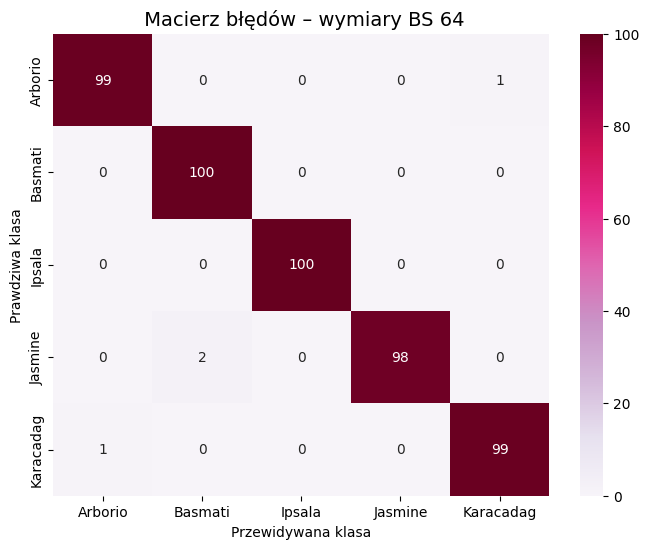

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary BS 64", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

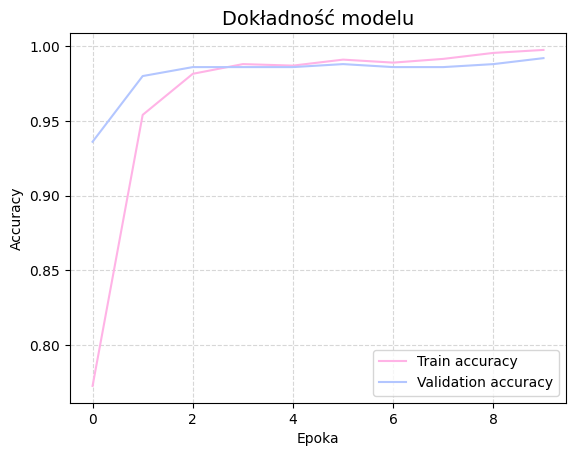

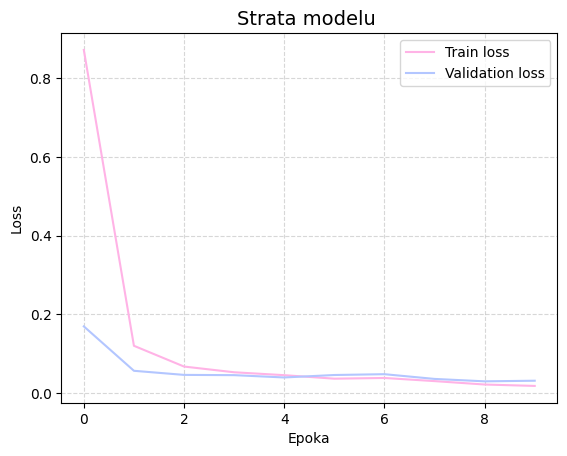

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BATCH_SIZE = 128

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 128
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('resnet50_rice_model_gpu_withTL_BS128.keras')

Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6046 - loss: 1.1495 - val_accuracy: 0.9340 - val_loss: 0.1750
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 143ms/step - accuracy: 0.9491 - loss: 0.1384 - val_accuracy: 0.9760 - val_loss: 0.0706
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9603 - loss: 0.1016 - val_accuracy: 0.9800 - val_loss: 0.0612
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9887 - loss: 0.0459 - val_accuracy: 0.9780 - val_loss: 0.0540
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.9906 - loss: 0.0418 - val_accuracy: 0.9880 - val_loss: 0.0443
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9889 - loss: 0.0388 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9968 - loss: 0.0275 - val_accuracy: 0.9920 - val_loss: 0.0384
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.9948 - loss: 0.0232 - val_accuracy: 0.9860 - val_l

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
              precision    recall  f1-score   support

     Arborio       0.99      0.97      0.98       100
     Basmati       0.97      0.99      0.98       100
      Ipsala       1.00      1.00      1.00       100
     Jasmine       0.99      0.97      0.98       100
   Karacadag       0.97      0.99      0.98       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



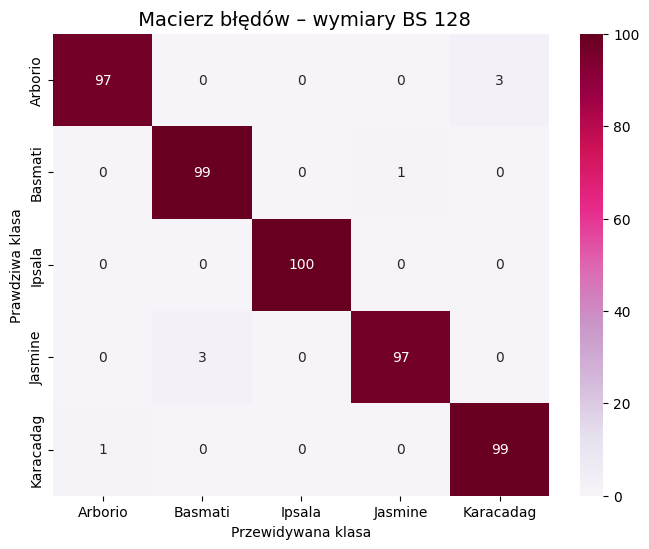

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – wymiary BS 128", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

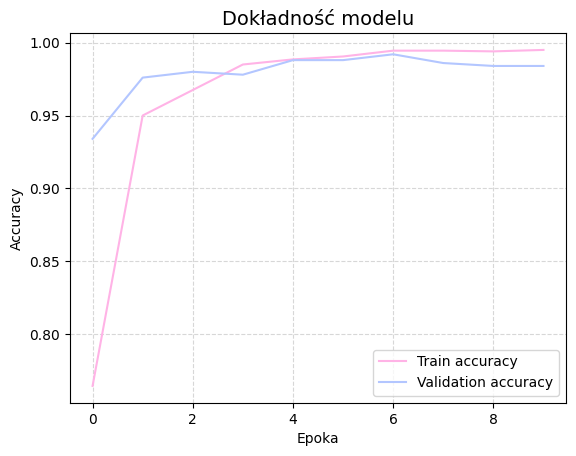

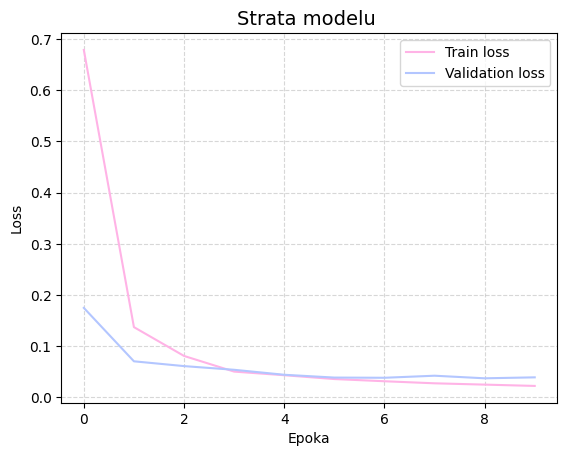

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#**Batch-size – raporty**

##Batch size = 32
Czas treningu: 0 min 42 s (≈ 0.70 min)

Dokł. treningowa: 99.1 %

Dokł. walidacyjna: 98.6 %

Najniższy val loss: 0.028 (Ep. 7)

Makro F1: 0.99

Uwagi:

Najstabilniejsze krzywe (płaskie val loss już od 3 epoki).

Delikatne wzrosty val loss w epokach 6–9, ale bez spadku dokładności.

##Batch size = 64
Czas treningu: 0 min 43 s (≈ 0.72 min)

Dokł. treningowa: 99.8 %

Dokł. walidacyjna: 99.2 %

Najniższy val loss: 0.029 (Ep. 9)

Makro F1: 0.99

Uwagi:

Najwyższa precyzja Basmati (1.00 / 1.00 / 1.00).

Val loss bardzo równy; kończy z najniższą średnią stratą

## Batch size = 128
Czas treningu: 1 min 07 s (≈ 1.12 min)

Dokł. treningowa: 99.5 %

Dokł. walidacyjna: 98.4 %

Najniższy val loss: 0.037 (Ep. 6)

Makro F1: 0.98

Uwagi:

Start wymagał 1 - 2 epok „rozruchu”, potem szybki spadek loss.

Nieco wyższe oscylacje val loss oraz najdłuższy czas epoki.

| Batch size | Czas treningu\* | Val Accuracy | Makro F1 | Najniższy val loss |
| ---------- | --------------- | ------------ | -------- | ------------------ |
| **32**     | **0 : 42 min**  | 0.986        | 0.99     | 0.028              |
| **64**     | 0 : 43 min      | **0.992**    | 0.99     | **0.029**          |
| **128**    | 1 : 07 min      | 0.984        | 0.98     | 0.037              |


Najwyższa dokładność uzyskana przy batch = 64 - bez wydłużenia czasu względem 32.

Batch = 32 daje prawie tę samą jakość przy minimalnym obciążeniu pamięci.

Batch = 128 nie poprawia wyników, a wydłuża epokę; warto tylko, gdy GPU lub pamięć pozwalają trenować jeszcze szybciej przez redukcję kroków optymalizera.

# G) RÓŻNE STRUKTURY SIECI

##  VGG16

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Model: VGG16")
print(f"✅ Batch size: {BATCH_SIZE}")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('vgg16_rice_model.keras')


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.5998 - loss: 3.4068 - val_accuracy: 0.9680 - val_loss: 0.1239
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9491 - loss: 0.1757 - val_accuracy: 0.9880 - val_loss: 0.0538
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9722 - loss: 0.0712 - val_accuracy: 0.9820 - val_loss: 0.0663
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9830 - loss: 0.0400 - val_accuracy: 0.9840 - val_loss: 0.0618
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9877 - loss: 0.0321 - val_accuracy: 0.9900 - val_loss: 0.0610
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9951 - loss: 0.0249 - val_accuracy: 0.9900 - val_loss: 0.0532
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9974 - loss: 0.0134 - val_accuracy: 0.9900 - val_loss: 0.0528
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9996 - loss: 0.0091 - val_accuracy: 0.9900 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.99      0.98       100
     Basmati       0.99      0.98      0.98       100
      Ipsala       1.00      0.98      0.99       100
     Jasmine       0.97      0.99      0.98       100
   Karacadag       0.99      0.98      0.98       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



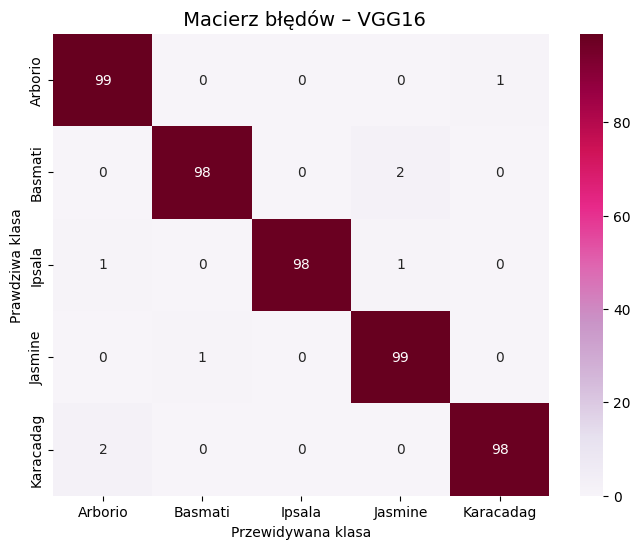

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – VGG16", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

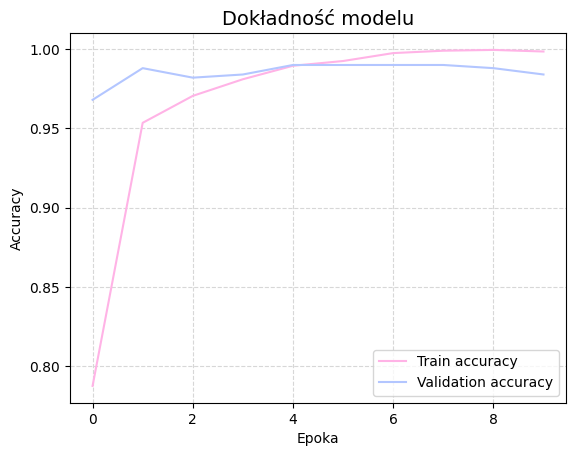

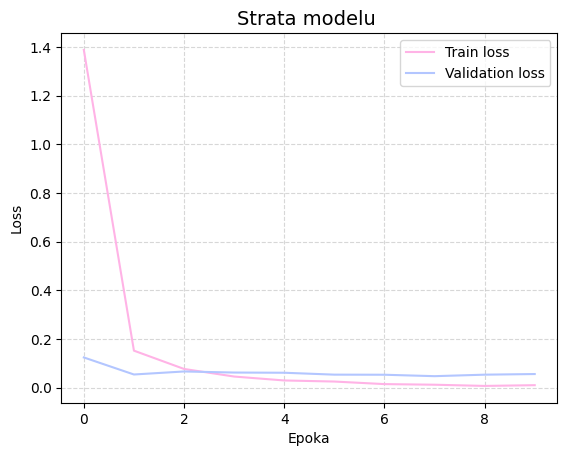

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## ResNet101

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Model: ResNet101")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('ResNet101_rice_model.keras')


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 339ms/step - accuracy: 0.7215 - loss: 0.7835 - val_accuracy: 0.9800 - val_loss: 0.0793
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9694 - loss: 0.0930 - val_accuracy: 0.9860 - val_loss: 0.0508
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9815 - loss: 0.0632 - val_accuracy: 0.9680 - val_loss: 0.0743
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9822 - loss: 0.0541 - val_accuracy: 0.9840 - val_loss: 0.0503
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9819 - loss: 0.0458 - val_accuracy: 0.9880 - val_loss: 0.0331
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9957 - loss: 0.0218 - val_accuracy: 0.9860 - val_loss: 0.0329
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9995 - loss: 0.0117 - val_accuracy: 0.9860 - val_loss: 0.0440
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9969 - loss: 0.0165 - val_accuracy: 0.9860 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 480ms/step
              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99       100
     Basmati       0.99      0.97      0.98       100
      Ipsala       1.00      0.99      0.99       100
     Jasmine       0.95      0.99      0.97       100
   Karacadag       1.00      0.99      0.99       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



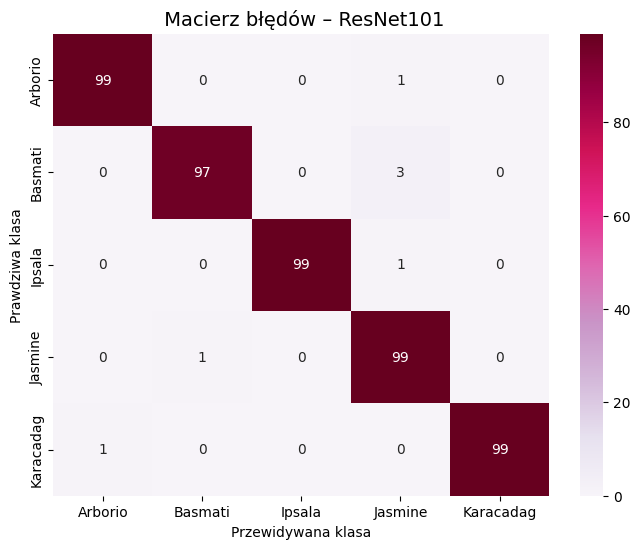

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – ResNet101", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

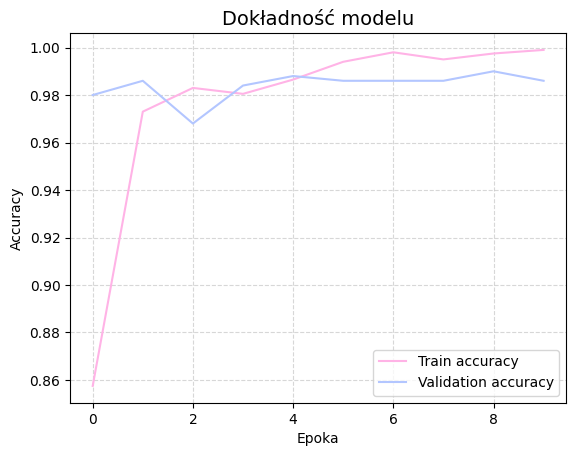

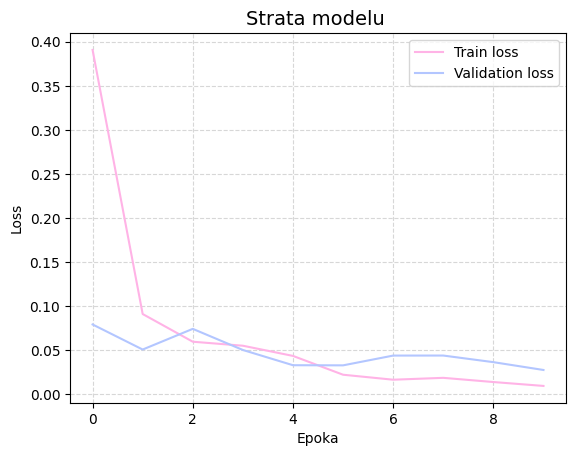

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##  InceptionV3

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Model: InceptionV3")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('InceptionV3_rice_model.keras')


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 510ms/step - accuracy: 0.4753 - loss: 9.2500 - val_accuracy: 0.8220 - val_loss: 0.5386
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.7628 - loss: 0.7116 - val_accuracy: 0.8880 - val_loss: 0.3245
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.8673 - loss: 0.4005 - val_accuracy: 0.8860 - val_loss: 0.3000
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.8689 - loss: 0.4846 - val_accuracy: 0.9280 - val_loss: 0.2017
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8541 - loss: 0.4998 - val_accuracy: 0.9400 - val_loss: 0.2176
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9088 - loss: 0.3029 - val_accuracy: 0.9240 - val_loss: 0.2497
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9224 - loss: 0.2090 - val_accuracy: 0.8740 - val_loss: 0.5458
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.8914 - loss: 0.3992 - val_accuracy: 0.8300

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 455ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.86      0.91       100
     Basmati       0.99      0.78      0.87       100
      Ipsala       1.00      0.97      0.98       100
     Jasmine       0.79      0.99      0.88       100
   Karacadag       0.89      0.97      0.93       100

    accuracy                           0.91       500
   macro avg       0.93      0.91      0.91       500
weighted avg       0.93      0.91      0.91       500



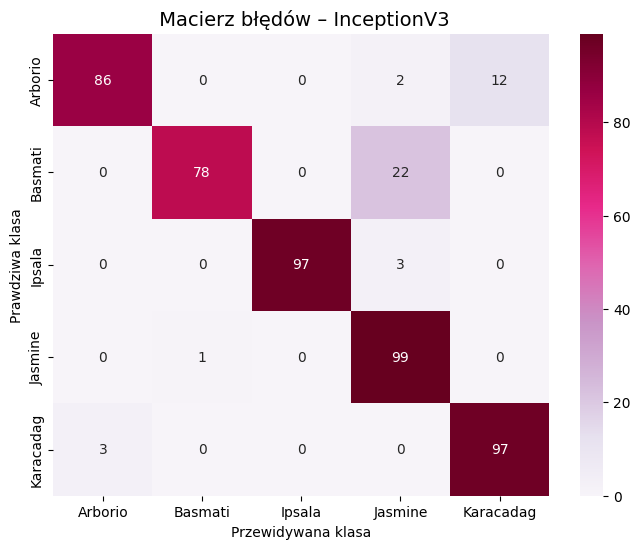

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – InceptionV3", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

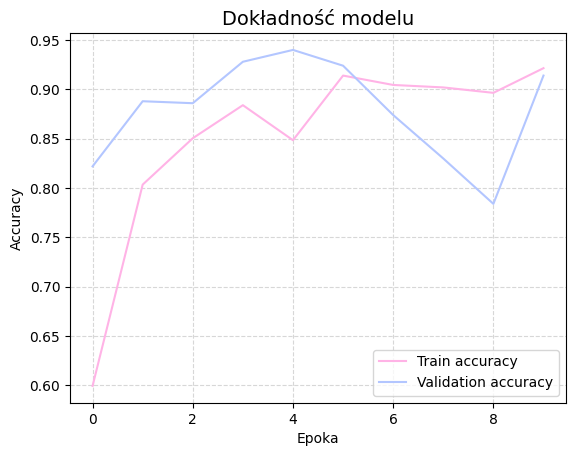

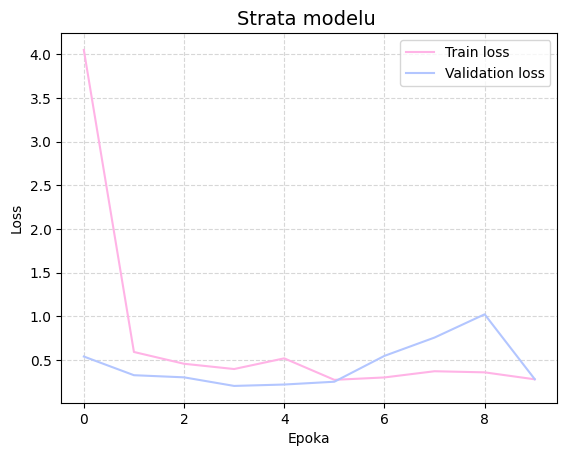

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import time

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 10

# === Przygotowanie danych ===
train_datagen = ImageDataGenerator(validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'rice_small_dataset',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# === Trening ===
start = time.time()
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS)
end = time.time()

# === Wyniki ===
print(f"✅ Model: MobileNetV2")
print(f"✅ Dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"✅ Dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")

model.save('MobileNetV2_rice_model.keras')


Found 2000 images belonging to 5 classes.
Found 500 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 179ms/step - accuracy: 0.7386 - loss: 0.6637 - val_accuracy: 0.9660 - val_loss: 0.1403
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9530 - loss: 0.1629 - val_accuracy: 0.9260 - val_loss: 0.1878
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9627 - loss: 0.1150 - val_accuracy: 0.9400 - val_loss: 0.1372
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9764 - loss: 0.0884 - val_accuracy: 0.9640 - val_loss: 0.0929
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9703 - loss: 0.0888 - val_accuracy: 0.9680 - val_loss: 0.0875
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9872 - loss: 0.0498 - val_accuracy: 0.9640 - val_loss: 0.0915
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9777 - loss: 0.0699 - val_accuracy: 0.9740 - val_loss: 0.0816
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9695 - loss: 0.0784 - val_accuracy: 0.9600 - val_loss: 

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.92      0.94       100
     Basmati       0.94      1.00      0.97       100
      Ipsala       0.98      1.00      0.99       100
     Jasmine       0.99      0.90      0.94       100
   Karacadag       0.93      0.99      0.96       100

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



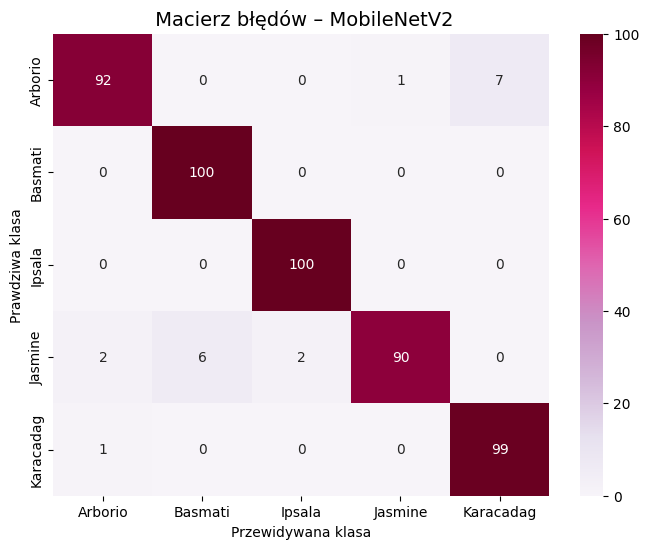

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – MobileNetV2", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

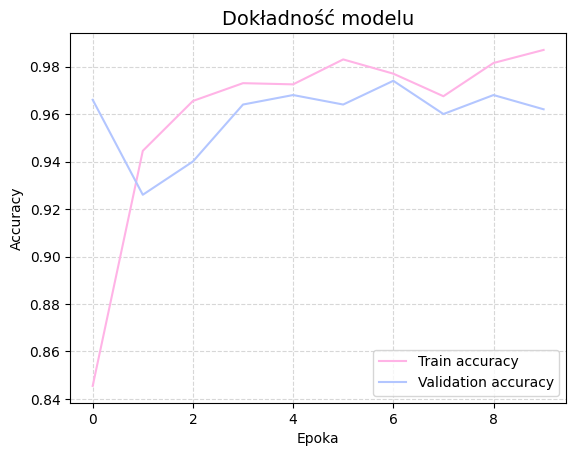

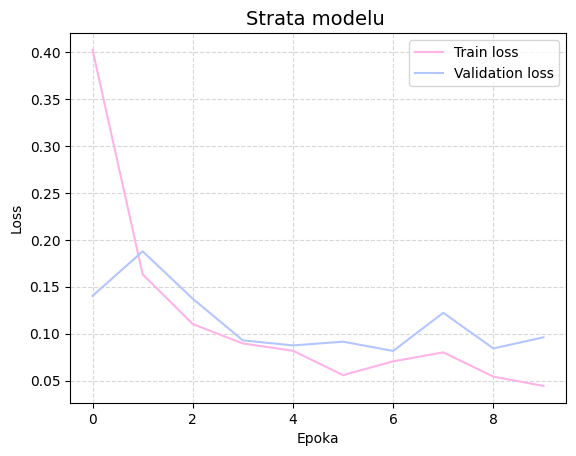

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#VGG16
Zalety:

Bardzo dobra dokładność (Val Acc: 98.4%, F1: 0.98)

Prosta i dobrze znana architektura

Stabilna przy klasyfikacji obrazów

Wady:

Bardzo duża liczba parametrów (ok. 138 mln)

Długi czas treningu na CPU lub bez GPU

#ResNet101
Zalety:

Najlepszy wynik (Val F1-score: 0.99)

Skuteczna generalizacja (residual blocks)

Głębsza sieć - lepiej wyłapuje złożone wzorce

Wady:

Większe zużycie pamięci RAM/VRAM


# InceptionV3
Zalety:

Bardzo dobra jakość po tuningu (Val F1-score: 0.91)

Efektywna struktura (rozbijanie konwolucji)

Lepsza wydajność przy ograniczonych zasobach niż VGG/ResNet

Wady:

Najdłuższy czas treningu (2.29 min)

Gorsze wyniki bez tuningu

Wrażliwy na dobór hiperparametrów

#MobileNetV2
Zalety:

Najszybszy model (0.64 min)

Bardzo lekka architektura (idealna do mobilnych aplikacji)

Wysoka jakość przy małym rozmiarze modelu (F1: 0.96)

Wady:

Minimalnie słabsza skuteczność niż ResNet/VGG

Mniej odporna na trudniejsze zbiory danych


#MEGA PODSUMOWANIE
| Model           | Trening Acc. | Val. Acc. | Val. F1-score (avg) | Czas treningu | Parametry startowe | Zalety                                      | Wady                                              |
| --------------- | ------------ | --------- | ------------------- | ------------- | ------------------ | ------------------------------------------- | ------------------------------------------------- |
| **VGG16**       | 99.95%       | 98.4%     | 0.98                | 0.78 min      | Wagi z ImageNet    | Stabilność, prostota, bardzo dobra jakość   | Bardzo duża liczba parametrów, wolny bez GPU      |
| **ResNet101**   | 99.87%       | 98.6%     | 0.99                | 1.18 min      | Wagi z ImageNet    | Głęboka architektura, świetna generalizacja | Długi czas treningu, duże zużycie pamięci         |
| **InceptionV3** | 92.15%       | 91.4%     | 0.91                | 2.29 min      | Wagi z ImageNet    | Dobre wyniki po tuningu, szybkie operacje   | Wrażliwy na hiperparametry, dłuższy czas treningu |
| **MobileNetV2** | 99.00%       | 96.2%     | 0.96                | 0.64 min      | Wagi z ImageNet    | Bardzo lekki, szybki, dobre wyniki          | Minimalnie niższa jakość niż ResNet/VGG           |


# MEGA EKSTRA SUPER DUPER MODEL CO MA WSZYSTKO WOAH

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import time
import os

# === Parametry ===
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 15
DATA_DIR = 'rice_dataset/Rice_Image_Dataset'
MODEL_NAME= 'mega_model.keras'

# === Augmentacja + Preprocessing ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrażamy warstwy ResNet50

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Regularizacja
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# === Callbacki ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(MODEL_NAME, monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# === Trening ===
start = time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)
end = time.time()

# === Wyniki ===
print(f"🏆 Finalna dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"🏆 Finalna dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")
model.save('rice_superMEGAmodel.keras')

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 268s 136ms/step - accuracy: 0.8696 - loss: 0.3985 - val_accuracy: 0.9477 - val_loss: 0.1336 - learning_rate: 0.0010
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 242s 129ms/step - accuracy: 0.9288 - loss: 0.1924 - val_accuracy: 0.9528 - val_loss: 0.1283 - learning_rate: 0.0010
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 236s 126ms/step - accuracy: 0.9332 - loss: 0.1850 - val_accuracy: 0.9491 - val_loss: 0.1337 - learning_rate: 0.0010
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 247s 131ms/step - accuracy: 0.9367 - loss: 0.1726 - val_accuracy: 0.9619 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 266s 133ms/step - accuracy: 0.9409 - loss: 0.1679 - val_accuracy: 0.9656 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 240s 128ms/step - accuracy: 0.9398 - loss: 0.1670 - val_accuracy: 0.9624 - val_loss: 0.1032 - learning_rate: 0.0010
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 263s 129ms

469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 108ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.97      0.97      3000
     Basmati       0.96      0.97      0.97      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       0.96      0.95      0.96      3000
   Karacadag       0.98      0.98      0.98      3000

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



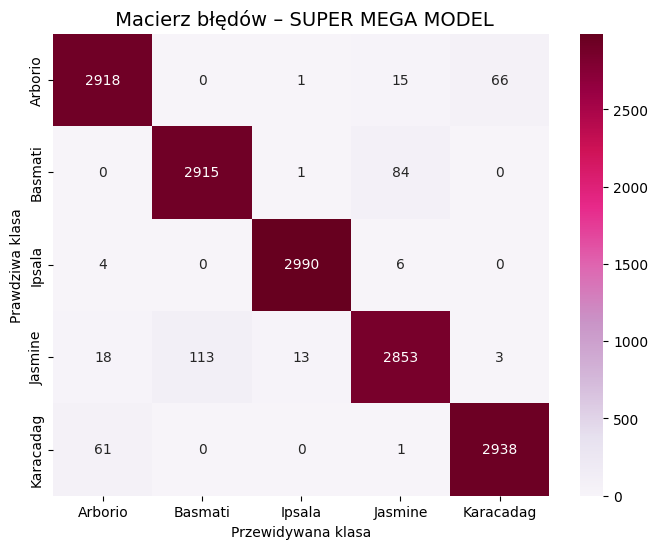

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – SUPER MEGA MODEL", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

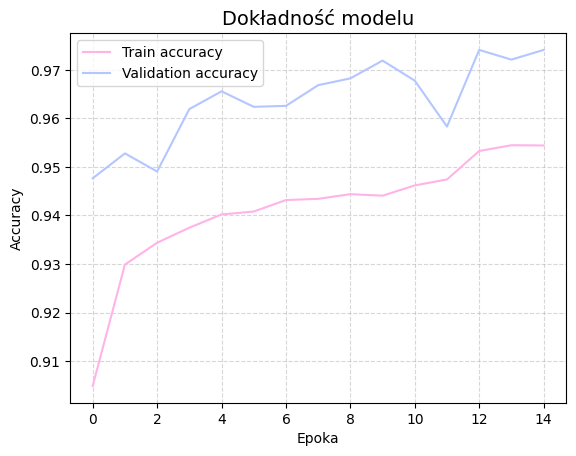

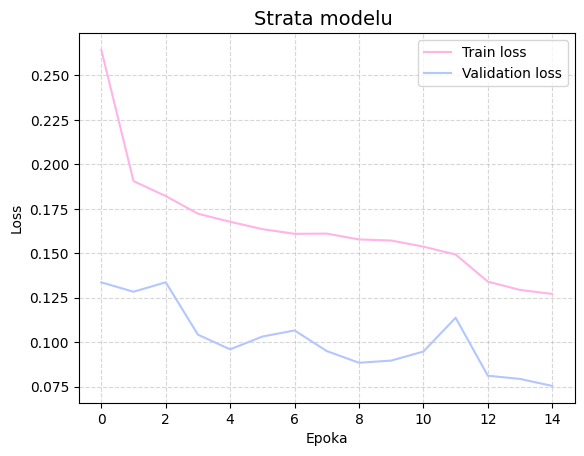

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import time
import os

# === Parametry ===
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 64
EPOCHS = 10
DATA_DIR = 'rice_dataset/Rice_Image_Dataset'
MODEL_NAME= 'mega_modelv2.keras'

# === Augmentacja + Preprocessing ===
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# === Budowa modelu ===
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
base_model.trainable = False  # Zamrażamy warstwy ResNet50

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Regularizacja
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# === Callbacki ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(MODEL_NAME, monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# === Trening ===
start = time.time()
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)
end = time.time()

# === Wyniki ===
print(f"🏆 Finalna dokładność treningowa: {history.history['accuracy'][-1]:.4f}")
print(f"🏆 Finalna dokładność walidacyjna: {history.history['val_accuracy'][-1]:.4f}")
print(f"⏱️ Czas treningu: {(end - start)/60:.2f} minut")
model.save('rice_superMEGAmodelv2.keras')

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 547s 561ms/step - accuracy: 0.8861 - loss: 0.3545 - val_accuracy: 0.9717 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 494s 527ms/step - accuracy: 0.9560 - loss: 0.1274 - val_accuracy: 0.9781 - val_loss: 0.0646 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 485s 517ms/step - accuracy: 0.9586 - loss: 0.1198 - val_accuracy: 0.9749 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 488s 520ms/step - accuracy: 0.9615 - loss: 0.1074 - val_accuracy: 0.9749 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 485s 518ms/step - accuracy: 0.9630 - loss: 0.1082 - val_accuracy: 0.9815 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 482s 514ms/step - accuracy: 0.9624 - loss: 0.1056 - val_accuracy: 0.9743 - val_loss: 0.0759 - learning_rate: 0.0010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 491s 523ms/step - accura

235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 436ms/step
              precision    recall  f1-score   support

     Arborio       0.97      0.98      0.98      3000
     Basmati       0.98      0.99      0.98      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       0.98      0.97      0.97      3000
   Karacadag       0.98      0.98      0.98      3000

    accuracy                           0.98     15000
   macro avg       0.98      0.98      0.98     15000
weighted avg       0.98      0.98      0.98     15000



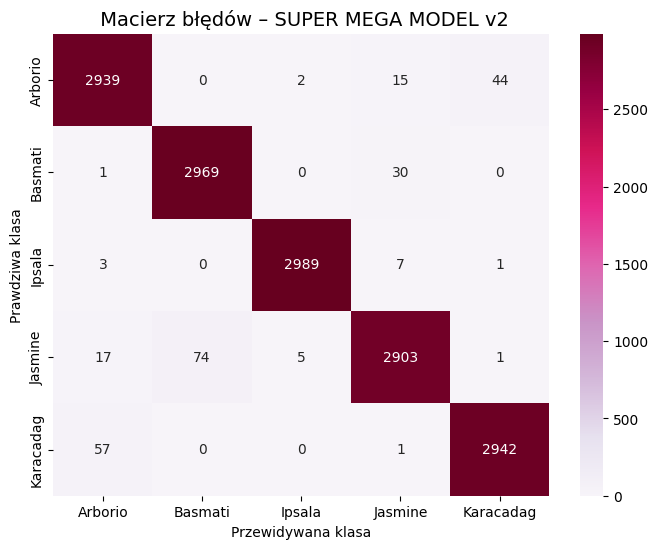

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import seaborn as sns

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred)

# Pastelowy heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=class_names, yticklabels=class_names)
plt.title(" Macierz błędów – SUPER MEGA MODEL v2", fontsize=14)
plt.xlabel("Przewidywana klasa")
plt.ylabel("Prawdziwa klasa")
plt.show()

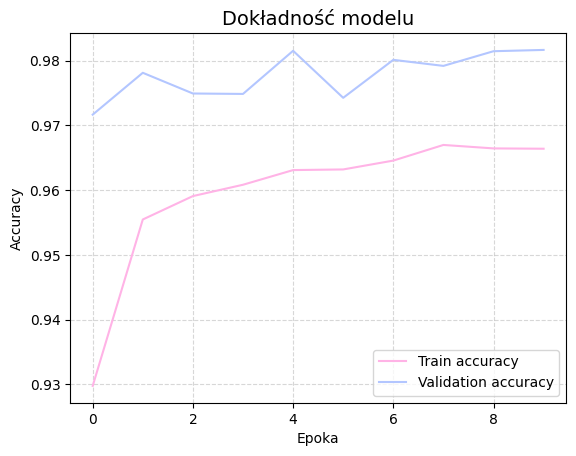

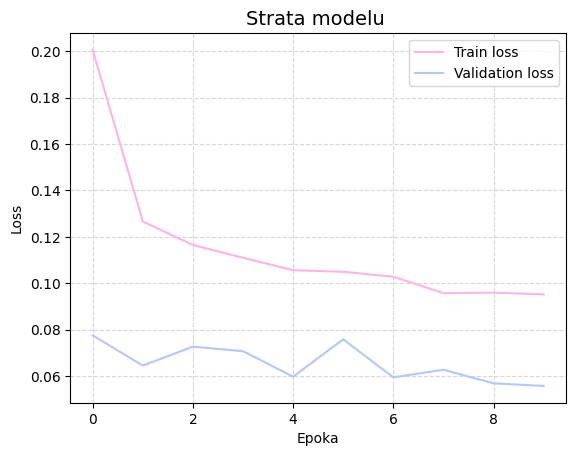

In [ ]:
import matplotlib.pyplot as plt

# Pastelowe kolory
train_color = '#ffb3e6'
val_color = '#b3c6ff'

# Dokładność
plt.plot(history.history['accuracy'], label='Train accuracy', color=train_color)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color=val_color)
plt.title('Dokładność modelu', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Strata
plt.plot(history.history['loss'], label='Train loss', color=train_color)
plt.plot(history.history['val_loss'], label='Validation loss', color=val_color)
plt.title('Strata modelu ', fontsize=14)
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()